# derived_8.4-regime-interpretation-1.1 — What Do the Regimes of Every Routing Strategy Physically Mean?

Follow-up of `derived_8.4-regime-interpretation-1.0`, with two changes:

1. The first-time-reader explanation of the model (clustering mechanism, feature-selection provenance, end-to-end mermaid diagram, leaderboard recap) moved out of the notebook and into this experiment's `README.md` (Part A).
2. The regime analysis is extended from the winning `Clustering_V0_Full_k2` router to **all five k2 routing strategies of `derived_8.4-eval-1.1`**: `Clustering_V0_Full_k2` (reference), `Clustering_Dynamic_k2`, `Seasonal_Binary_k2`, `Univariate_G_API_k2`, `Trained_Gating_k2`.

For each strategy we characterize what its two regimes physically mean: which stations land in which regime (and with what purity, on trainval and out-of-sample test), the distribution of the target and of weather/dynamic/static features per regime, seasonality and year composition, and which of the 50 V0 features separate the regimes best. Everything below reproduces the exact eval-1.1 routers (fitted on the `derived_8.4` train+val split) and is verified against the labels eval-1.1 saved to disk.


In [1]:
"""Setup: reproduce the eval-1.1 routers for all five k2 strategies on derived_8.4."""
from __future__ import annotations

import importlib.util
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

# Notebook lives in notebooks/experiment/derived_8.4-regime-interpretation-1.1/
PROJECT_ROOT = Path("../../..").resolve()
SPLIT_DIR = PROJECT_ROOT / "data" / "splits" / "derived_8.4"
EVAL_DIR = PROJECT_ROOT / "notebooks" / "experiment" / "derived_8.4-eval-1.1"
EXP_DIR = Path(".").resolve()


# --- Load splits (same preparation as eval-1.1 eval11/data.py) ---
def load_frame(path: Path) -> pd.DataFrame:
    base = pd.read_csv(path)
    dates = pd.to_datetime(base["date"], errors="raise")
    derived = pd.DataFrame(
        {"date": dates, "month": dates.dt.month.astype(int), "year": dates.dt.year.astype(int)}
    )
    # splits already contain a raw "year" column; drop it to avoid duplicates
    return pd.concat([base.drop(columns=["date", "month", "year"], errors="ignore"), derived], axis=1)


train = load_frame(SPLIT_DIR / "train.csv")
val = load_frame(SPLIT_DIR / "val.csv")
test = load_frame(SPLIT_DIR / "test.csv")
trainval = pd.concat([train, val], axis=0, ignore_index=True)

# --- Load the 50 V0 features from dataset metadata ---
spec = importlib.util.spec_from_file_location("dataset_metadata", SPLIT_DIR / "dataset_metadata.py")
metadata = importlib.util.module_from_spec(spec)
spec.loader.exec_module(metadata)
V0_FEATURES = list(metadata.OVERALL_SELECTED_FEATURES_V0)
TARGET = "soil_moisture_5cm"

# --- Import the exact router classes used by eval-1.1 ---
sys.path.insert(0, str(EVAL_DIR))
from eval11.routers import (  # noqa: E402
    DynamicClusterRouter,
    SeasonalBinaryRouter,
    TrainedGatingRouter,
    UnivariateGAPIRouter,
    V0FullRouter,
)

# TrainedGatingRouter defaults to device="cuda", but this environment has no GPU,
# so the gate classifier is refit on CPU (labels verified against eval-1.1 below).
ROUTER_FACTORIES = {
    "Clustering_V0_Full_k2": lambda: V0FullRouter(V0_FEATURES, seed=42),
    "Clustering_Dynamic_k2": lambda: DynamicClusterRouter(seed=42),
    "Seasonal_Binary_k2": lambda: SeasonalBinaryRouter(),
    "Univariate_G_API_k2": lambda: UnivariateGAPIRouter(),
    "Trained_Gating_k2": lambda: TrainedGatingRouter(V0_FEATURES, seed=42, device="cpu"),
}

labels = {}
for strategy, factory in ROUTER_FACTORIES.items():
    router = factory()
    router.fit(trainval)
    labels[(strategy, "trainval")] = router.predict(trainval)
    labels[(strategy, "test")] = router.predict(test)

print(f"trainval: {len(trainval)} rows  |  test: {len(test)} rows  |  V0 features: {len(V0_FEATURES)}")
for strategy in ROUTER_FACTORIES:
    lt, lv = labels[(strategy, "trainval")], labels[(strategy, "test")]
    print(
        f"{strategy:24s} trainval 0 -> {int((lt == 0).sum())}, 1 -> {int((lt == 1).sum())}"
        f"  |  test 0 -> {int((lv == 0).sum())}, 1 -> {int((lv == 1).sum())}"
    )

trainval: 14608 rows  |  test: 6620 rows  |  V0 features: 50
Clustering_V0_Full_k2    trainval 0 -> 10624, 1 -> 3984  |  test 0 -> 4817, 1 -> 1803
Clustering_Dynamic_k2    trainval 0 -> 7974, 1 -> 6634  |  test 0 -> 3717, 1 -> 2903
Seasonal_Binary_k2       trainval 0 -> 7559, 1 -> 7049  |  test 0 -> 3415, 1 -> 3205
Univariate_G_API_k2      trainval 0 -> 7304, 1 -> 7304  |  test 0 -> 3513, 1 -> 3107
Trained_Gating_k2        trainval 0 -> 4181, 1 -> 10427  |  test 0 -> 1936, 1 -> 4684


## 2. Sanity check against eval-1.1

eval-1.1 saved the test labels of every evaluated candidate as `models/*_labels_te.npy` (labels do not depend on the per-cluster delta configuration, so the winner files are representative). We compare our refit labels against them: the four deterministic strategies (`Clustering_V0_Full_k2`, `Clustering_Dynamic_k2`, `Seasonal_Binary_k2`, `Univariate_G_API_k2`) must match exactly; `Trained_Gating_k2` was trained on CUDA in eval-1.1 and is refit on CPU here, so we require ≥ 99% agreement and report the exact rate. We also keep the 1.0-style count check for the winning router.

In [2]:
"""Sanity check: labels must match eval-1.1's saved test labels."""
EVAL_MODELS = EVAL_DIR / "models"
expected_files = {
    "Clustering_V0_Full_k2": "Clustering_V0_Full_k2_winner_labels_te.npy",
    "Clustering_Dynamic_k2": "Clustering_Dynamic_k2_winner_labels_te.npy",
    "Seasonal_Binary_k2": "Seasonal_Binary_k2_winner_labels_te.npy",
    "Univariate_G_API_k2": "Univariate_G_API_k2_winner_labels_te.npy",
    "Trained_Gating_k2": "Trained_Gating_k2_winner_labels_te.npy",
}

print("--- Test-label agreement with eval-1.1 (models/*_winner_labels_te.npy) ---")
for strategy, fname in expected_files.items():
    expected = np.load(EVAL_MODELS / fname)
    got = labels[(strategy, "test")]
    agree = float((expected == got).mean())
    n_match = int((expected == got).sum())
    print(f"{strategy:24s} agreement = {agree:.6f}  ({n_match}/{len(expected)} rows)")
    if strategy == "Trained_Gating_k2":
        assert agree >= 0.99, f"Trained_Gating_k2 agreement below 99%: {agree:.6f}"
    else:
        assert agree == 1.0, f"{strategy} labels differ from eval-1.1"

# Count check for the winning router (same check as 1.0).
expected_counts = {"trainval": (10624, 3984), "test": (4817, 1803)}
actual_counts = {
    "trainval": (
        int((labels[("Clustering_V0_Full_k2", "trainval")] == 0).sum()),
        int((labels[("Clustering_V0_Full_k2", "trainval")] == 1).sum()),
    ),
    "test": (
        int((labels[("Clustering_V0_Full_k2", "test")] == 0).sum()),
        int((labels[("Clustering_V0_Full_k2", "test")] == 1).sum()),
    ),
}
for split_name, exp in expected_counts.items():
    got = actual_counts[split_name]
    status = "OK" if got == exp else "MISMATCH"
    print(f"{split_name:9s} expected {exp}  got {got}  -> {status}")
assert actual_counts == expected_counts, "V0-Full counts differ from eval-1.1"
print("All strategies verified: identical regimes to eval-1.1.")

--- Test-label agreement with eval-1.1 (models/*_winner_labels_te.npy) ---
Clustering_V0_Full_k2    agreement = 1.000000  (6620/6620 rows)
Clustering_Dynamic_k2    agreement = 1.000000  (6620/6620 rows)
Seasonal_Binary_k2       agreement = 1.000000  (6620/6620 rows)
Univariate_G_API_k2      agreement = 1.000000  (6620/6620 rows)
Trained_Gating_k2        agreement = 0.996828  (6599/6620 rows)
trainval  expected (10624, 3984)  got (10624, 3984)  -> OK
test      expected (4817, 1803)  got (4817, 1803)  -> OK
All strategies verified: identical regimes to eval-1.1.


## 3. Per-strategy regime interpretation

The function below generalizes sections 7–13 of `derived_8.4-regime-interpretation-1.0` to any k2 strategy: regime sizes, target distribution (KDE + statistics), month-of-year composition, year composition, station composition & purity (trainval and out-of-sample test) with a geographic map, weather/dynamic driver medians with rank-biserial effect sizes, static environmental attributes, and the top-15 of the 50 V0 features separating the two regimes (the same comparability convention as `derived_8.4-gating-analysis-1.0`). All tables and figures are saved with a `_<strategy>` suffix so artifacts never collide across strategies or with 1.0.

In [3]:
"""Generalized per-regime interpretation for one k2 routing strategy."""
DRIVERS = ["precip_mm", "G_API", "G_rain_sum_7d", "LST_modis", "SMAP_sm_pm_interp", "G_DSLR", "F_NDVI"]
STATIC_ATTRS = ["latitude", "longitude", "elev", "slope", "J_soil_texture_usda_b0", "J_lc_code", "J_bio_bio13"]


def rank_biserial(a: pd.Series, b: pd.Series) -> float:
    """Rank-biserial correlation (Mann-Whitney U effect size) between two groups, -1..+1."""
    a, b = a.dropna(), b.dropna()
    if len(a) == 0 or len(b) == 0:
        return float("nan")
    u, _ = mannwhitneyu(a, b, alternative="two-sided")
    n_a, n_b = len(a), len(b)
    return 2.0 * (u - n_a * n_b / 2.0) / (n_a * n_b)


def interpret_regimes(strategy: str) -> None:
    """Per-regime physical interpretation for one k2 routing strategy (trainval + test)."""
    lbl_tr = labels[(strategy, "trainval")]
    lbl_te = labels[(strategy, "test")]
    clusters = sorted(np.unique(lbl_tr))
    palette = {0: "#D95F02", 1: "#1B9E77"}

    print(f"\n{'=' * 78}\nINTERPRETATION: {strategy}\n{'=' * 78}")

    # 1. Regime sizes
    size_rows = []
    for split_name, lbl in [("trainval", lbl_tr), ("test", lbl_te)]:
        n = len(lbl)
        for c in clusters:
            cnt = int((lbl == c).sum())
            size_rows.append({"split": split_name, "cluster": c, "n": cnt, "share": f"{cnt / n:.1%}"})
    df_sizes = pd.DataFrame(size_rows)
    print("\n--- Regime sizes ---")
    print(df_sizes.to_markdown(index=False))

    # 2. Target characterization
    stats_rows = []
    for c in clusters:
        s = trainval.loc[lbl_tr == c, TARGET]
        stats_rows.append({
            "cluster": c, "n": int(s.count()), "mean": round(float(s.mean()), 4),
            "std": round(float(s.std()), 4), "p10": round(float(s.quantile(0.10)), 4),
            "p50": round(float(s.median()), 4), "p90": round(float(s.quantile(0.90)), 4),
        })
    df_target_stats = pd.DataFrame(stats_rows)
    df_target_stats["mean_shift_vs_global"] = (df_target_stats["mean"] - trainval[TARGET].mean()).round(4)
    print("\n--- Target (soil_moisture_5cm) statistics per regime (trainval) ---")
    print(df_target_stats.to_markdown(index=False))

    fig, ax = plt.subplots(figsize=(8, 5))
    for c in clusters:
        mask = lbl_tr == c
        sns.kdeplot(trainval.loc[mask, TARGET], label=f"Cluster {c} (n={int(mask.sum())})",
                    fill=True, alpha=0.25, color=palette[c], linewidth=2, ax=ax)
    ax.axvline(trainval[TARGET].mean(), color="black", linestyle="--", alpha=0.6, label="Global mean")
    ax.set_title(f"Soil moisture distribution by regime ({strategy}, trainval)")
    ax.set_xlabel(TARGET)
    ax.legend()
    fig.tight_layout()
    fig.savefig(EXP_DIR / f"regime_target_distributions_{strategy}.png", dpi=300)
    plt.show()

    # 3. Seasonality: share of each cluster by month
    month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
    season_rows = []
    for split_name, frame, lbl in [("trainval", trainval, lbl_tr), ("test", test, lbl_te)]:
        for m in range(1, 13):
            mask = frame["month"] == m
            n_m = int(mask.sum())
            if n_m == 0:
                continue
            for c in clusters:
                season_rows.append({
                    "split": split_name, "month": month_names[m - 1], "cluster": c,
                    "share": int((lbl[mask] == c).sum()) / n_m,
                })
    df_season = pd.DataFrame(season_rows)
    pivot_season = df_season.pivot_table(index="month", columns=["split", "cluster"], values="share").reindex(month_names)
    print("\n--- Share of rows in each cluster by month (1.0 = all rows of that month) ---")
    print(pivot_season.round(3).to_markdown())

    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
    for ax, split_name in zip(axes, ["trainval", "test"]):
        sub = df_season[df_season["split"] == split_name]
        for c in clusters:
            part = sub[sub["cluster"] == c]
            ax.bar(part["month"], part["share"], color=palette[c], label=f"cluster {c}")
        ax.set_title(f"{split_name}: regime share by month ({strategy})")
        ax.set_ylabel("share")
        ax.legend()
    fig.tight_layout()
    fig.savefig(EXP_DIR / f"regime_seasonality_{strategy}.png", dpi=300)
    plt.show()

    # 4. Year composition
    year_rows = []
    for split_name, frame, lbl in [("trainval", trainval, lbl_tr), ("test", test, lbl_te)]:
        for y in sorted(frame["year"].unique()):
            mask = frame["year"] == y
            n_y = int(mask.sum())
            for c in clusters:
                year_rows.append({"split": split_name, "year": int(y), "cluster": c,
                                  "share": int((lbl[mask] == c).sum()) / n_y})
    df_year = pd.DataFrame(year_rows)
    pivot_year = df_year.pivot_table(index="year", columns=["split", "cluster"], values="share")
    print("\n--- Share of each cluster per year ---")
    print(pivot_year.round(3).to_markdown())

    # 5. Station composition & purity (trainval + out-of-sample test)
    station_rows = []
    for sid, group in trainval.groupby("station_id"):
        g_lbl = lbl_tr[trainval["station_id"] == sid]
        n = len(group)
        shares = {c: float((g_lbl == c).mean()) for c in clusters}
        dominant = int(max(shares, key=shares.get))
        station_rows.append({
            "station_id": sid, "n": n,
            **{f"share_c{c}": round(shares[c], 4) for c in clusters},
            "dominant_cluster": dominant,
            "purity": round(shares[dominant], 4),
            "longitude": float(group["longitude"].iloc[0]),
            "latitude": float(group["latitude"].iloc[0]),
        })
    df_stations = pd.DataFrame(station_rows).sort_values("share_c1", ascending=False)
    print("\n--- Station composition (trainval) ---")
    print(df_stations.to_markdown(index=False))
    print(f"Mean station purity (trainval): {df_stations['purity'].mean():.3f}")

    fig, ax = plt.subplots(figsize=(8, 7))
    for _, row in df_stations.iterrows():
        color = palette[int(row["dominant_cluster"])]
        ax.scatter(row["longitude"], row["latitude"], s=220, color=color, edgecolor="black",
                   linewidth=1.2, zorder=3)
        ax.annotate(row["station_id"], (row["longitude"], row["latitude"]),
                    textcoords="offset points", xytext=(0, 10), ha="center", fontsize=8)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"Dominant regime per station ({strategy}, trainval)")
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(EXP_DIR / f"regime_geographic_distribution_{strategy}.png", dpi=300)
    plt.show()

    test_rows = []
    for sid, group in test.groupby("station_id"):
        g_lbl = lbl_te[test["station_id"] == sid]
        n = len(group)
        shares = {c: float((g_lbl == c).mean()) for c in clusters}
        dominant = int(max(shares, key=shares.get))
        test_rows.append({
            "station_id": sid, "n_test": n,
            **{f"share_c{c}_test": round(shares[c], 4) for c in clusters},
            "dominant_cluster_test": dominant,
            "purity_test": round(shares[dominant], 4),
        })
    df_stations_test = pd.DataFrame(test_rows).sort_values("share_c1_test", ascending=False)
    print("\n--- Station composition & purity on the TEST split (out-of-sample) ---")
    print(df_stations_test.to_markdown(index=False))
    print(f"Mean test purity: {df_stations_test['purity_test'].mean():.3f}")

    # 6. Weather / dynamic drivers
    driver_rows = []
    for feat in DRIVERS:
        g0 = trainval.loc[lbl_tr == 0, feat]
        g1 = trainval.loc[lbl_tr == 1, feat]
        driver_rows.append({
            "feature": feat,
            "median_cluster0": round(float(g0.median()), 4),
            "median_cluster1": round(float(g1.median()), 4),
            "rank_biserial_r": round(rank_biserial(g0, g1), 3),
        })
    df_drivers = pd.DataFrame(driver_rows)
    print("\n--- Weather / dynamic drivers per regime (trainval; r > 0 => higher in cluster 1) ---")
    print(df_drivers.to_markdown(index=False))

    plot_df = pd.concat([trainval, pd.DataFrame({"cluster": lbl_tr}, index=trainval.index)], axis=1)
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    for ax, feat in zip(axes.ravel(), ["precip_mm", "G_API", "G_rain_sum_7d", "LST_modis", "SMAP_sm_pm_interp", "G_DSLR"]):
        sns.boxenplot(data=plot_df, x="cluster", y=feat, hue="cluster",
                      palette=[palette[c] for c in clusters], legend=False, ax=ax)
        ax.set_title(feat)
        ax.set_xlabel("cluster")
    fig.suptitle(f"Weather / dynamic drivers by regime ({strategy}, trainval)", fontweight="bold")
    fig.tight_layout()
    fig.savefig(EXP_DIR / f"regime_weather_drivers_{strategy}.png", dpi=300)
    plt.show()

    # 7. Static / environmental attributes
    static_rows = []
    for feat in STATIC_ATTRS:
        g0 = trainval.loc[lbl_tr == 0, feat]
        g1 = trainval.loc[lbl_tr == 1, feat]
        static_rows.append({
            "feature": feat,
            "median_cluster0": round(float(g0.median()), 3),
            "median_cluster1": round(float(g1.median()), 3),
            "rank_biserial_r": round(rank_biserial(g0, g1), 3),
        })
    df_static = pd.DataFrame(static_rows)
    print("\n--- Static / environmental attributes per regime (trainval) ---")
    print(df_static.to_markdown(index=False))

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    for ax, feat in zip(axes.ravel(), ["latitude", "longitude", "elev", "slope", "J_soil_texture_usda_b0", "J_lc_code"]):
        sns.boxenplot(data=plot_df, x="cluster", y=feat, hue="cluster",
                      palette=[palette[c] for c in clusters], legend=False, ax=ax)
        ax.set_title(feat)
        ax.set_xlabel("cluster")
    fig.suptitle(f"Static / environmental attributes by regime ({strategy}, trainval)", fontweight="bold")
    fig.tight_layout()
    fig.savefig(EXP_DIR / f"regime_static_attributes_{strategy}.png", dpi=300)
    plt.show()

    # 8. Top-15 of the 50 V0 features separating the regimes
    rank_rows = []
    for feat in V0_FEATURES:
        g0 = trainval.loc[lbl_tr == 0, feat]
        g1 = trainval.loc[lbl_tr == 1, feat]
        r = rank_biserial(g0, g1)
        if np.isnan(r):
            continue
        rank_rows.append({
            "feature": feat,
            "median_cluster0": round(float(g0.median()), 4),
            "median_cluster1": round(float(g1.median()), 4),
            "rank_biserial_r": round(r, 3),
        })
    df_rank = pd.DataFrame(rank_rows).sort_values("rank_biserial_r", key=lambda s: s.abs(), ascending=False)
    print("\n--- Top 15 V0 features separating the regimes (trainval; r > 0 => higher in cluster 1) ---")
    print(df_rank.head(15).to_markdown(index=False))

    # 9. Export (profile, station composition incl. test purity, top features)
    profile_rows = []
    for feat in [TARGET] + DRIVERS + STATIC_ATTRS:
        g0 = trainval.loc[lbl_tr == 0, feat]
        g1 = trainval.loc[lbl_tr == 1, feat]
        profile_rows.append({
            "feature": feat,
            "median_cluster0": round(float(g0.median()), 4),
            "median_cluster1": round(float(g1.median()), 4),
            "rank_biserial_r": round(rank_biserial(g0, g1), 3),
        })
    df_profile = pd.DataFrame(profile_rows)
    df_profile.to_csv(EXP_DIR / f"regime_profile_summary_{strategy}.csv", index=False)
    df_stations = df_stations.merge(df_stations_test, on="station_id")
    df_stations.to_csv(EXP_DIR / f"regime_station_composition_{strategy}.csv", index=False)
    df_rank.to_csv(EXP_DIR / f"regime_top_features_{strategy}.csv", index=False)
    print(f"\nSaved regime_profile_summary_{strategy}.csv, regime_station_composition_{strategy}.csv, "
          f"regime_top_features_{strategy}.csv")

### 3.1 Clustering_V0_Full_k2 (winning router, reference)

The full treatment for the winning router, identical in spirit to `derived_8.4-regime-interpretation-1.0` sections 7–13 (now with the merged station CSV and the top-features export).


INTERPRETATION: Clustering_V0_Full_k2

--- Regime sizes ---


| split    |   cluster |     n | share   |
|:---------|----------:|------:|:--------|
| trainval |         0 | 10624 | 72.7%   |
| trainval |         1 |  3984 | 27.3%   |
| test     |         0 |  4817 | 72.8%   |
| test     |         1 |  1803 | 27.2%   |

--- Target (soil_moisture_5cm) statistics per regime (trainval) ---
|   cluster |     n |   mean |    std |   p10 |   p50 |   p90 |   mean_shift_vs_global |
|----------:|------:|-------:|-------:|------:|------:|------:|-----------------------:|
|         0 | 10624 | 0.2216 | 0.107  | 0.041 | 0.239 | 0.347 |                 0.0033 |
|         1 |  3984 | 0.2094 | 0.1098 | 0.044 | 0.244 | 0.335 |                -0.0089 |


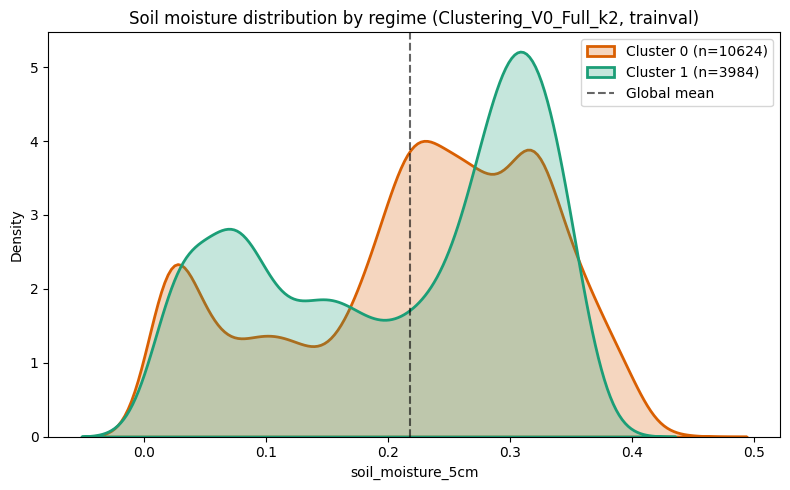


--- Share of rows in each cluster by month (1.0 = all rows of that month) ---
| month   |   ('test', 0) |   ('test', 1) |   ('trainval', 0) |   ('trainval', 1) |
|:--------|--------------:|--------------:|------------------:|------------------:|
| Jan     |         0.758 |         0.242 |             0.766 |             0.234 |
| Feb     |         0.781 |         0.219 |             0.779 |             0.221 |
| Mar     |         0.728 |         0.272 |             0.733 |             0.267 |
| Apr     |         0.7   |         0.3   |             0.714 |             0.286 |
| May     |         0.7   |         0.3   |             0.714 |             0.286 |
| Jun     |         0.707 |         0.293 |             0.712 |             0.288 |
| Jul     |         0.728 |         0.272 |             0.714 |             0.286 |
| Aug     |         0.713 |         0.287 |             0.706 |             0.294 |
| Sep     |         0.723 |         0.277 |             0.699 |             0.301

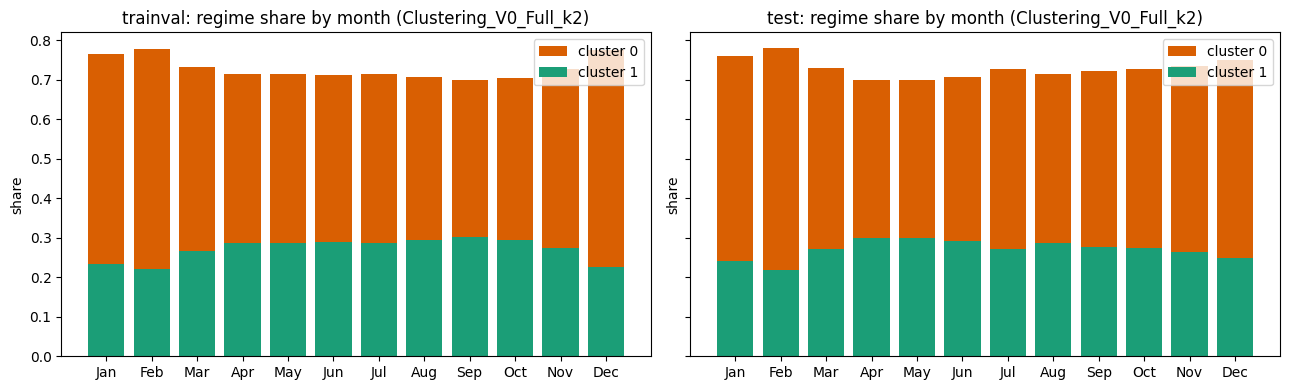


--- Share of each cluster per year ---
|   year |   ('test', 0) |   ('test', 1) |   ('trainval', 0) |   ('trainval', 1) |
|-------:|--------------:|--------------:|------------------:|------------------:|
|   2017 |       nan     |       nan     |             0.732 |             0.268 |
|   2018 |       nan     |       nan     |             0.729 |             0.271 |
|   2019 |       nan     |       nan     |             0.736 |             0.264 |
|   2020 |       nan     |       nan     |             0.723 |             0.277 |
|   2021 |       nan     |       nan     |             0.719 |             0.281 |
|   2022 |       nan     |       nan     |             0.725 |             0.275 |
|   2023 |         0.733 |         0.267 |           nan     |           nan     |
|   2024 |         0.703 |         0.297 |           nan     |           nan     |
|   2025 |         0.751 |         0.249 |           nan     |           nan     |

--- Station composition (trainval) ---
| stati

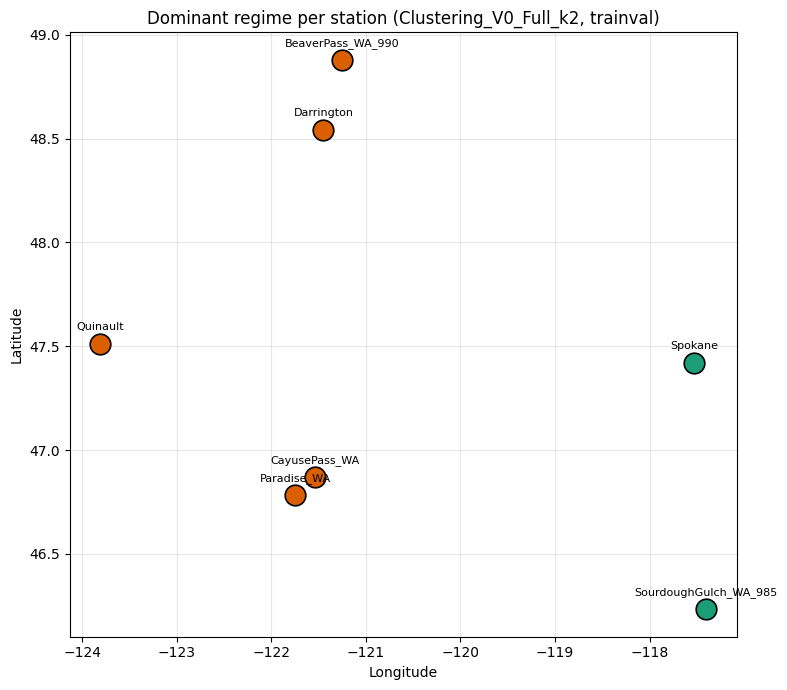


--- Station composition & purity on the TEST split (out-of-sample) ---
| station_id            |   n_test |   share_c0_test |   share_c1_test |   dominant_cluster_test |   purity_test |
|:----------------------|---------:|----------------:|----------------:|------------------------:|--------------:|
| Spokane               |      897 |               0 |               1 |                       1 |             1 |
| SourdoughGulch_WA_985 |      906 |               0 |               1 |                       1 |             1 |
| BeaverPass_WA_990     |      626 |               1 |               0 |                       0 |             1 |
| Darrington            |      999 |               1 |               0 |                       0 |             1 |
| CayusePass_WA         |     1081 |               1 |               0 |                       0 |             1 |
| Quinault              |     1044 |               1 |               0 |                       0 |             1 |
| Paradi

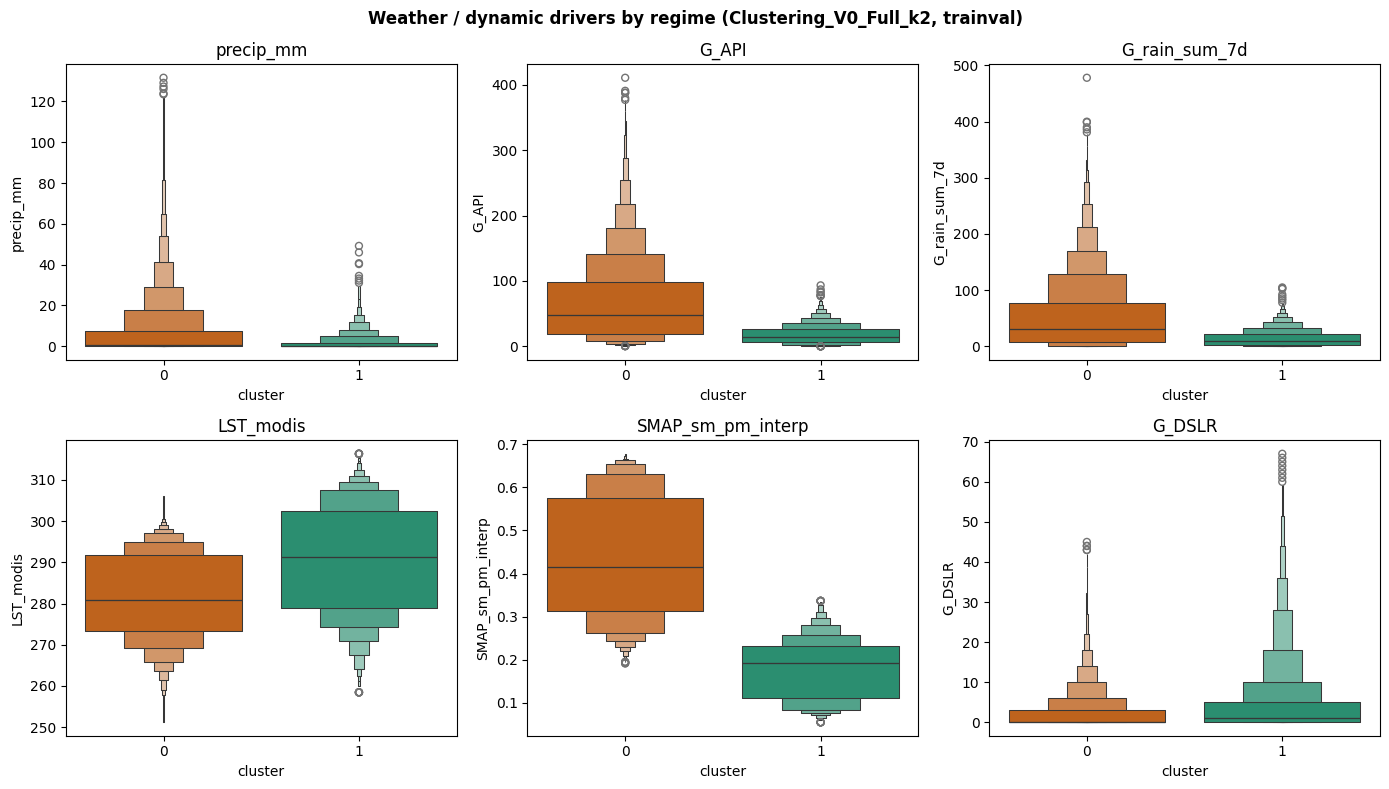


--- Static / environmental attributes per regime (trainval) ---
| feature                |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:-----------------------|------------------:|------------------:|------------------:|
| latitude               |            47.51  |            46.233 |             0.642 |
| longitude              |          -121.534 |          -117.4   |            -1     |
| elev                   |          1205.09  |          1160.53  |             0.208 |
| slope                  |            18.149 |            20.225 |             0.112 |
| J_soil_texture_usda_b0 |             7     |             7     |             0.398 |
| J_lc_code              |            10     |            30     |            -0.55  |
| J_bio_bio13            |           391     |            70     |             1     |


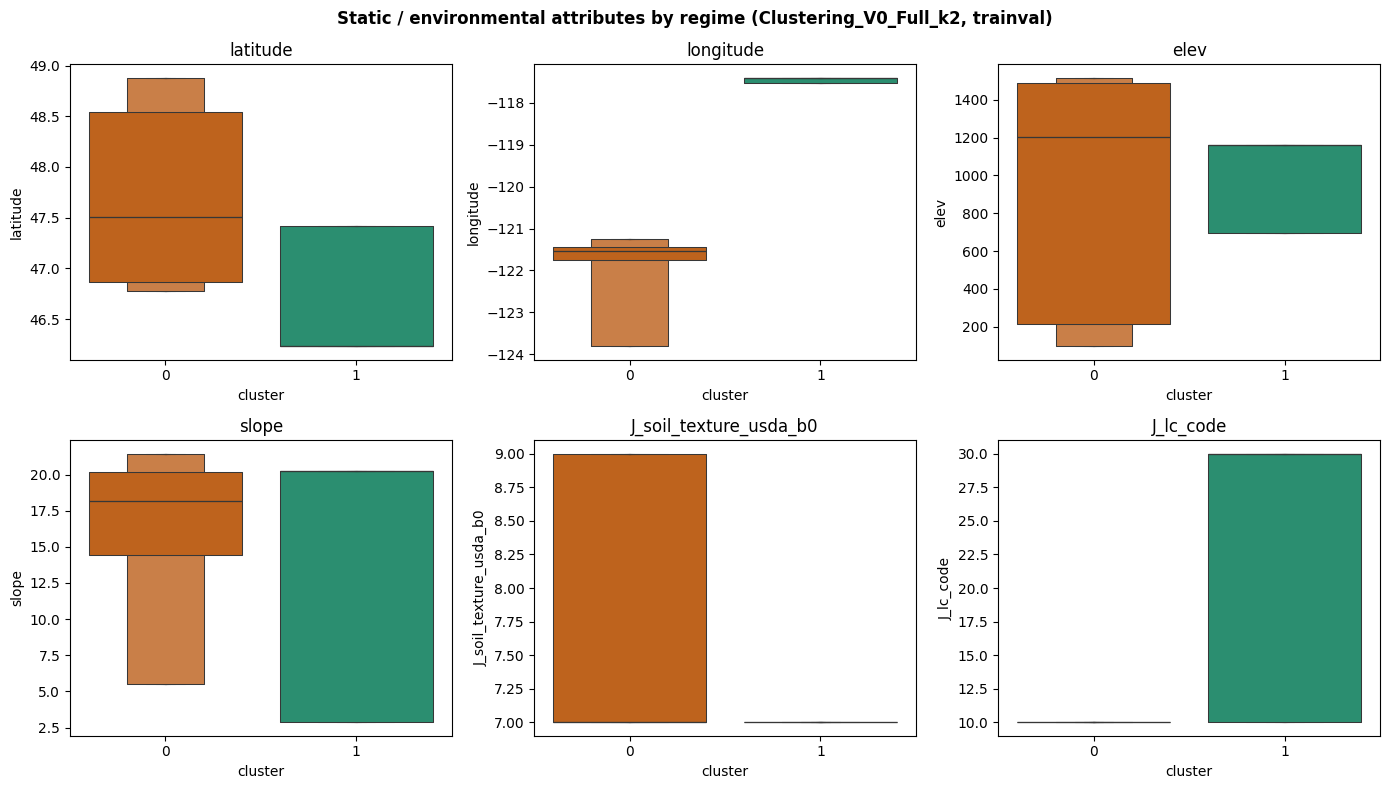


--- Top 15 V0 features separating the regimes (trainval; r > 0 => higher in cluster 1) ---
| feature                      |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:-----------------------------|------------------:|------------------:|------------------:|
| K_aspect_cos                 |           -0.5    |           -0.891  |             1     |
| J_bio_bio15                  |           61      |           34      |             1     |
| J_clay_wfrac_b100            |            9      |           23      |            -1     |
| J_bio_bio02                  |           97      |          133      |            -1     |
| SMAP_sm_pm_interp_rollmean30 |            0.4147 |            0.1945 |             0.951 |
| V_ema_SMAP_sm_interp_kobs30  |            0.3702 |            0.1838 |             0.946 |
| SMAP_sm_pm_interp_lag30      |            0.4142 |            0.1931 |             0.93  |
| V_rollmin_s2_b12_kobs30      |            0.0458 |            0.137  

In [4]:
interpret_regimes("Clustering_V0_Full_k2")

### 3.2 Clustering_Dynamic_k2

The same treatment for the KMeans router that clusters on only 3 dynamic features (`SMAP_sm_pm_interp_lag1`, `G_API`, `LST_modis`). With no static/terrain inputs, its regimes cannot be purely station-geographic by construction.


INTERPRETATION: Clustering_Dynamic_k2

--- Regime sizes ---
| split    |   cluster |    n | share   |
|:---------|----------:|-----:|:--------|
| trainval |         0 | 7974 | 54.6%   |
| trainval |         1 | 6634 | 45.4%   |
| test     |         0 | 3717 | 56.1%   |
| test     |         1 | 2903 | 43.9%   |

--- Target (soil_moisture_5cm) statistics per regime (trainval) ---
|   cluster |    n |   mean |    std |   p10 |   p50 |   p90 |   mean_shift_vs_global |
|----------:|-----:|-------:|-------:|------:|------:|------:|-----------------------:|
|         0 | 7974 | 0.18   | 0.1183 | 0.027 | 0.174 | 0.341 |                -0.0383 |
|         1 | 6634 | 0.2643 | 0.0702 | 0.186 | 0.272 | 0.342 |                 0.046  |


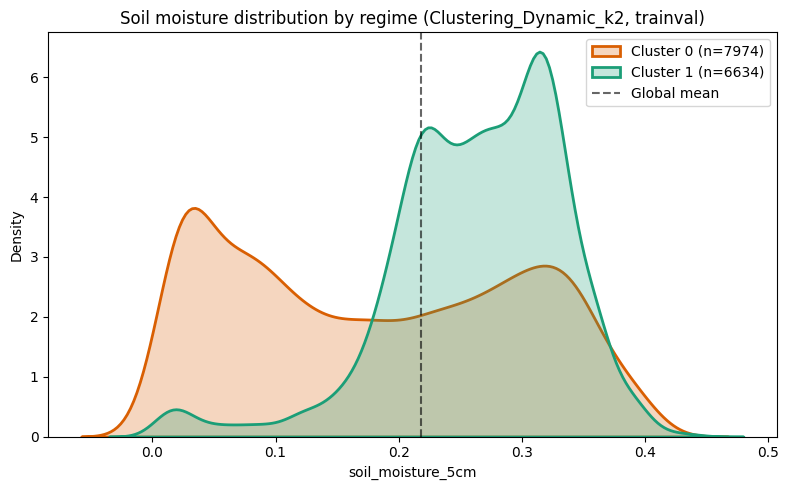


--- Share of rows in each cluster by month (1.0 = all rows of that month) ---
| month   |   ('test', 0) |   ('test', 1) |   ('trainval', 0) |   ('trainval', 1) |
|:--------|--------------:|--------------:|------------------:|------------------:|
| Jan     |         0.017 |         0.983 |             0.012 |             0.988 |
| Feb     |         0.061 |         0.939 |             0.06  |             0.94  |
| Mar     |         0.253 |         0.747 |             0.309 |             0.691 |
| Apr     |         0.483 |         0.517 |             0.471 |             0.529 |
| May     |         0.939 |         0.061 |             0.847 |             0.153 |
| Jun     |         0.975 |         0.025 |             0.952 |             0.048 |
| Jul     |         1     |         0     |             1     |             0     |
| Aug     |         1     |         0     |             1     |             0     |
| Sep     |         0.981 |         0.019 |             0.92  |             0.08 

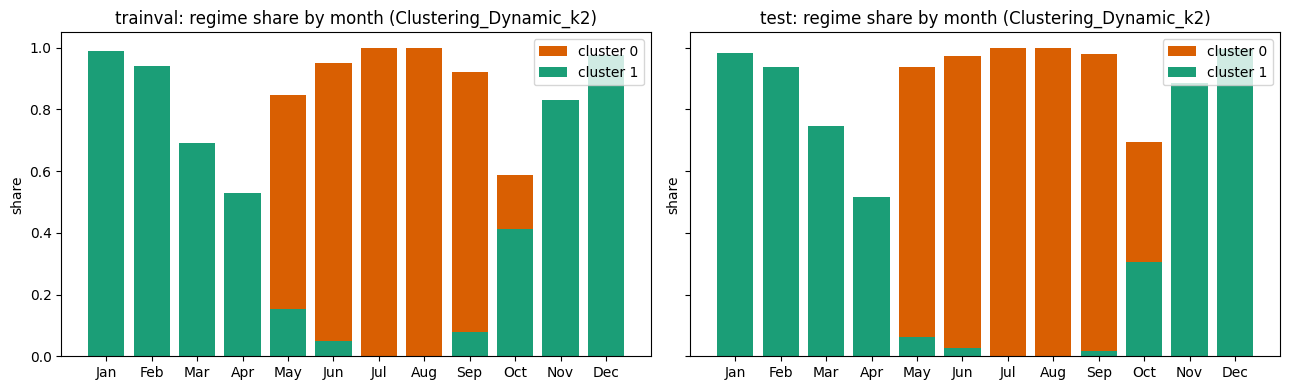


--- Share of each cluster per year ---
|   year |   ('test', 0) |   ('test', 1) |   ('trainval', 0) |   ('trainval', 1) |
|-------:|--------------:|--------------:|------------------:|------------------:|
|   2017 |       nan     |       nan     |             0.531 |             0.469 |
|   2018 |       nan     |       nan     |             0.573 |             0.427 |
|   2019 |       nan     |       nan     |             0.567 |             0.433 |
|   2020 |       nan     |       nan     |             0.556 |             0.444 |
|   2021 |       nan     |       nan     |             0.552 |             0.448 |
|   2022 |       nan     |       nan     |             0.493 |             0.507 |
|   2023 |         0.57  |         0.43  |           nan     |           nan     |
|   2024 |         0.563 |         0.437 |           nan     |           nan     |
|   2025 |         0.548 |         0.452 |           nan     |           nan     |

--- Station composition (trainval) ---
| stati

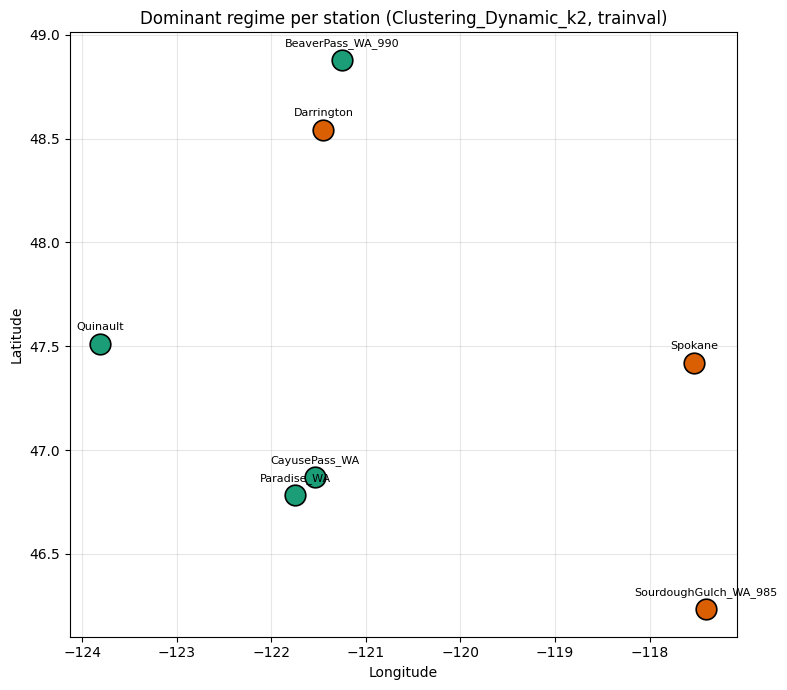


--- Station composition & purity on the TEST split (out-of-sample) ---
| station_id            |   n_test |   share_c0_test |   share_c1_test |   dominant_cluster_test |   purity_test |
|:----------------------|---------:|----------------:|----------------:|------------------------:|--------------:|
| BeaverPass_WA_990     |      626 |          0.4137 |          0.5863 |                       1 |        0.5863 |
| Paradise_WA           |     1067 |          0.4564 |          0.5436 |                       1 |        0.5436 |
| CayusePass_WA         |     1081 |          0.4625 |          0.5375 |                       1 |        0.5375 |
| Quinault              |     1044 |          0.4895 |          0.5105 |                       1 |        0.5105 |
| Darrington            |      999 |          0.6136 |          0.3864 |                       0 |        0.6136 |
| SourdoughGulch_WA_985 |      906 |          0.6821 |          0.3179 |                       0 |        0.6821 |
| Spokan

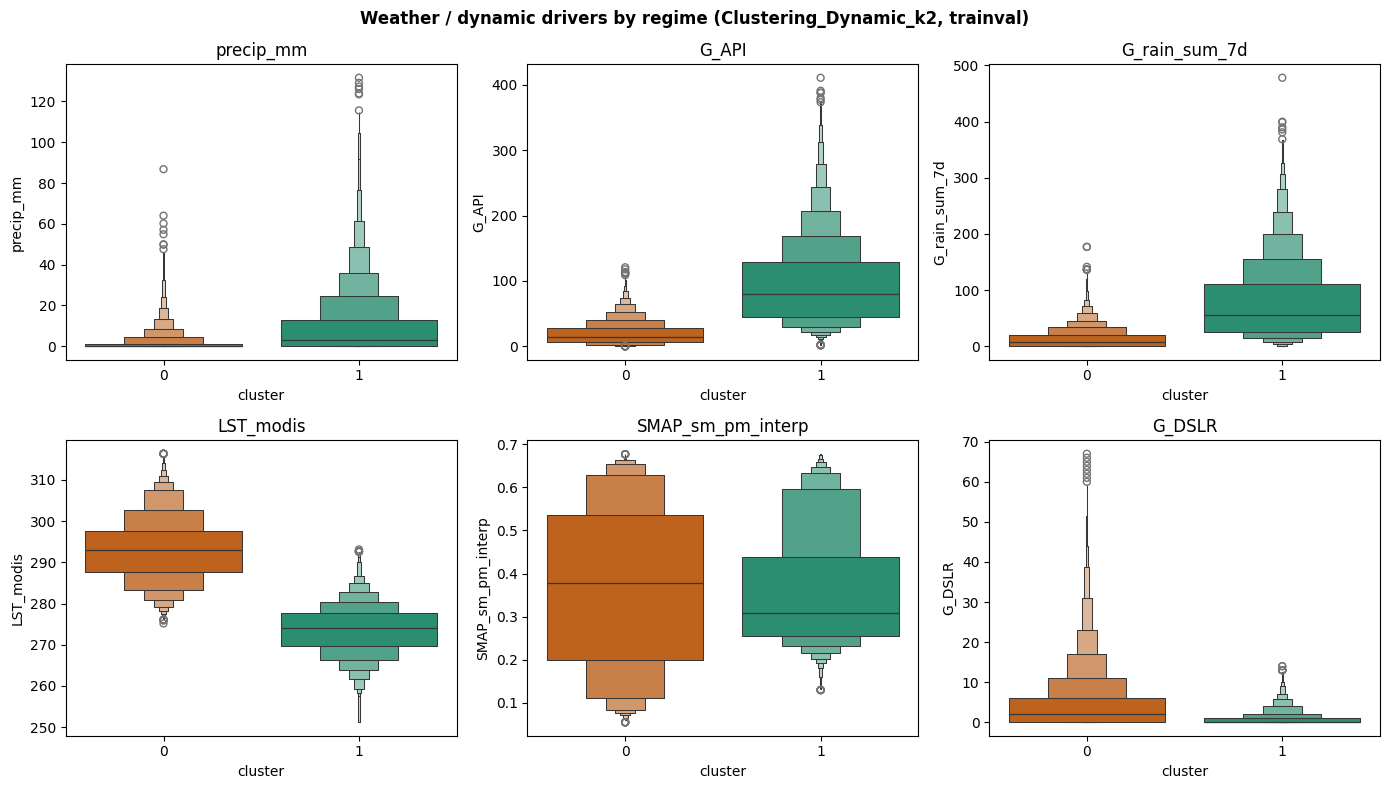


--- Static / environmental attributes per regime (trainval) ---
| feature                |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:-----------------------|------------------:|------------------:|------------------:|
| latitude               |            47.42  |            47.51  |            -0.102 |
| longitude              |          -121.255 |          -121.534 |             0.238 |
| elev                   |          1160.53  |          1205.09  |            -0.122 |
| slope                  |            18.149 |            18.149 |            -0.12  |
| J_soil_texture_usda_b0 |             7     |             7     |            -0.137 |
| J_lc_code              |            10     |            10     |             0.096 |
| J_bio_bio13            |           204     |           391     |            -0.26  |


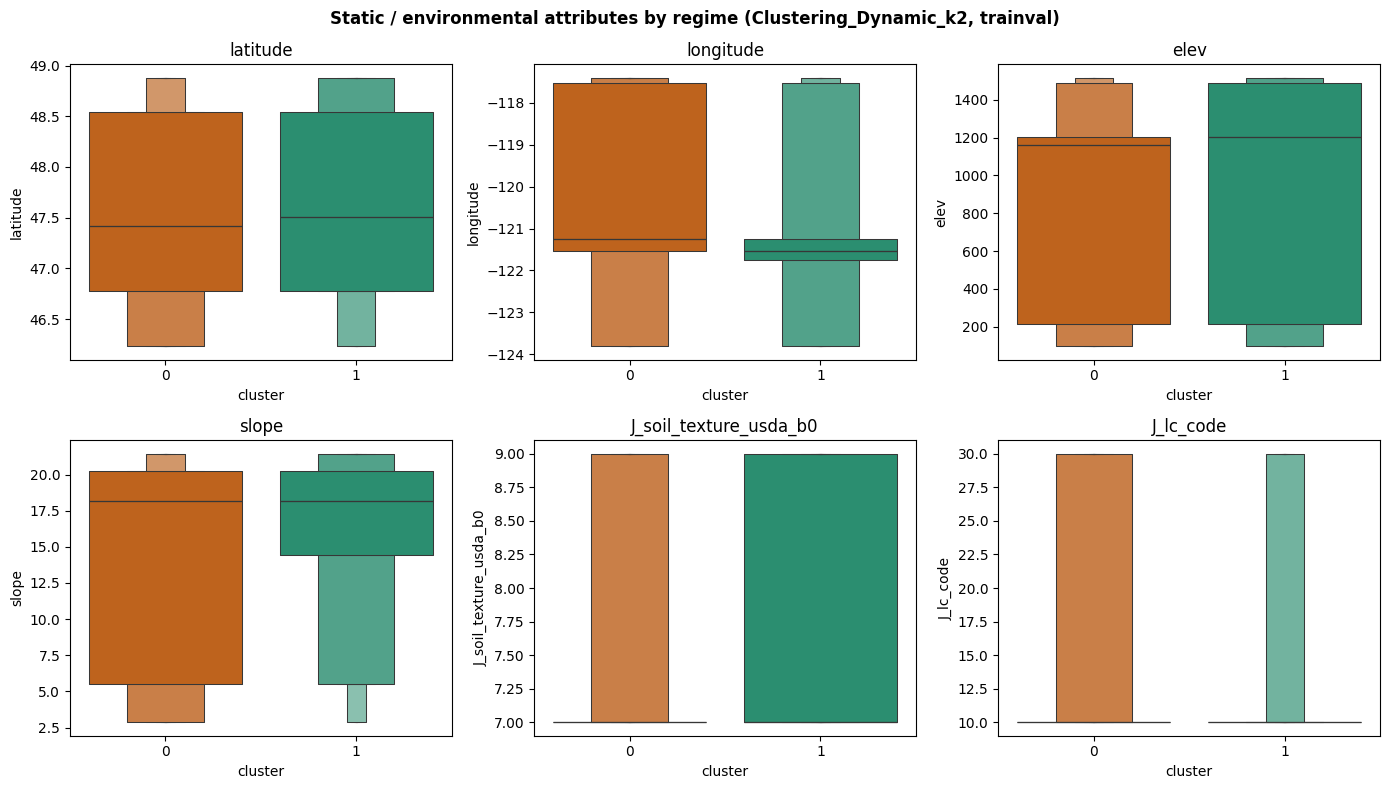


--- Top 15 V0 features separating the regimes (trainval; r > 0 => higher in cluster 1) ---
| feature                  |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:-------------------------|------------------:|------------------:|------------------:|
| V_ema_LST_modis_kobs30   |          292.467  |          274.156  |             0.9   |
| V_rollmax_G_API_kobs7    |           19.9743 |          101.385  |            -0.842 |
| V_ema_G_API_kobs30       |           18.1371 |           82.2554 |            -0.824 |
| V_rollmin_G_API_kobs14   |            8.4994 |           48.6017 |            -0.808 |
| V_rollmax_G_API_kobs30   |           33.1763 |          144.73   |            -0.808 |
| V_rollrng_G_API_kobs30   |           25.5925 |           98.823  |            -0.773 |
| F_MSI                    |            0.5477 |            0.3611 |             0.528 |
| s2_b11                   |            0.1522 |            0.0912 |             0.52  |
| V_rollmin_s2_b12

In [5]:
interpret_regimes("Clustering_Dynamic_k2")

### 3.3 Seasonal_Binary_k2

The calendar router (dry May–Oct vs wet Nov–Apr) is temporal by construction: its regimes are exactly two halves of the year, so station composition and purity answer a different question — whether the dry/wet calendar seasons line up with station geography or cut through stations.


INTERPRETATION: Seasonal_Binary_k2

--- Regime sizes ---
| split    |   cluster |    n | share   |
|:---------|----------:|-----:|:--------|
| trainval |         0 | 7559 | 51.7%   |
| trainval |         1 | 7049 | 48.3%   |
| test     |         0 | 3415 | 51.6%   |
| test     |         1 | 3205 | 48.4%   |

--- Target (soil_moisture_5cm) statistics per regime (trainval) ---
|   cluster |    n |   mean |    std |   p10 |   p50 |   p90 |   mean_shift_vs_global |
|----------:|-----:|-------:|-------:|------:|------:|------:|-----------------------:|
|         0 | 7559 | 0.1717 | 0.1183 | 0.025 | 0.155 | 0.342 |                -0.0466 |
|         1 | 7049 | 0.2682 | 0.0656 | 0.189 | 0.277 | 0.341 |                 0.0499 |


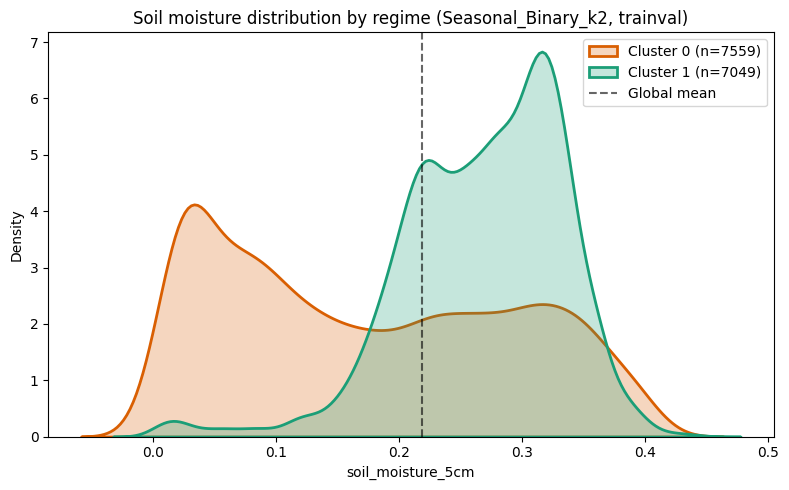


--- Share of rows in each cluster by month (1.0 = all rows of that month) ---
| month   |   ('test', 0) |   ('test', 1) |   ('trainval', 0) |   ('trainval', 1) |
|:--------|--------------:|--------------:|------------------:|------------------:|
| Jan     |             0 |             1 |                 0 |                 1 |
| Feb     |             0 |             1 |                 0 |                 1 |
| Mar     |             0 |             1 |                 0 |                 1 |
| Apr     |             0 |             1 |                 0 |                 1 |
| May     |             1 |             0 |                 1 |                 0 |
| Jun     |             1 |             0 |                 1 |                 0 |
| Jul     |             1 |             0 |                 1 |                 0 |
| Aug     |             1 |             0 |                 1 |                 0 |
| Sep     |             1 |             0 |                 1 |                 0

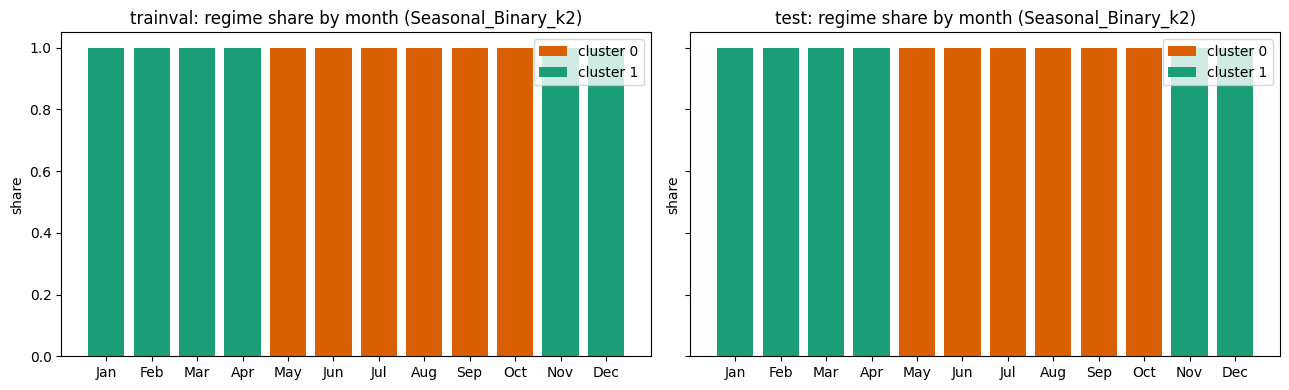


--- Share of each cluster per year ---
|   year |   ('test', 0) |   ('test', 1) |   ('trainval', 0) |   ('trainval', 1) |
|-------:|--------------:|--------------:|------------------:|------------------:|
|   2017 |       nan     |       nan     |             0.521 |             0.479 |
|   2018 |       nan     |       nan     |             0.518 |             0.482 |
|   2019 |       nan     |       nan     |             0.531 |             0.469 |
|   2020 |       nan     |       nan     |             0.509 |             0.491 |
|   2021 |       nan     |       nan     |             0.514 |             0.486 |
|   2022 |       nan     |       nan     |             0.512 |             0.488 |
|   2023 |         0.542 |         0.458 |           nan     |           nan     |
|   2024 |         0.503 |         0.497 |           nan     |           nan     |
|   2025 |         0.501 |         0.499 |           nan     |           nan     |

--- Station composition (trainval) ---
| stati

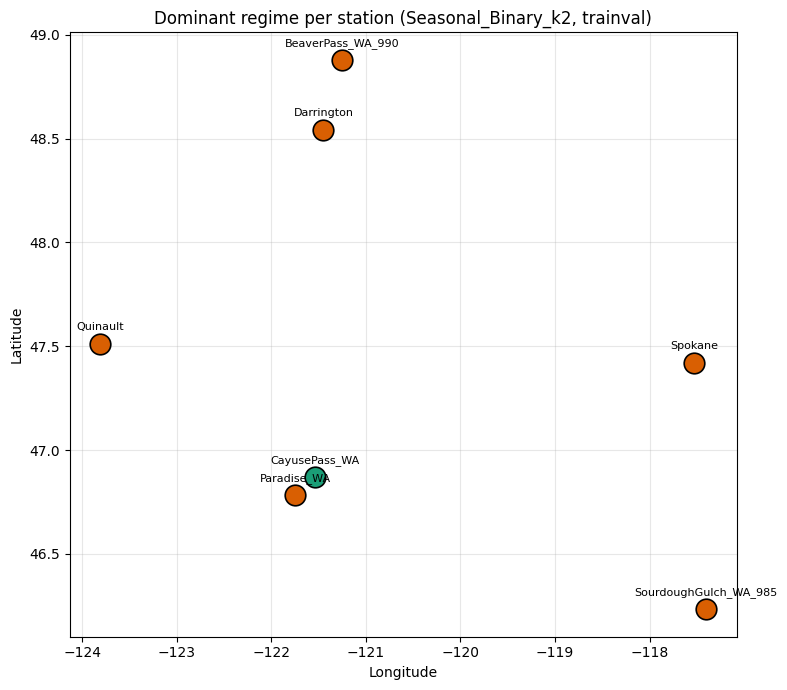


--- Station composition & purity on the TEST split (out-of-sample) ---
| station_id            |   n_test |   share_c0_test |   share_c1_test |   dominant_cluster_test |   purity_test |
|:----------------------|---------:|----------------:|----------------:|------------------------:|--------------:|
| BeaverPass_WA_990     |      626 |          0.4601 |          0.5399 |                       1 |        0.5399 |
| SourdoughGulch_WA_985 |      906 |          0.4669 |          0.5331 |                       1 |        0.5331 |
| Paradise_WA           |     1067 |          0.4902 |          0.5098 |                       1 |        0.5098 |
| CayusePass_WA         |     1081 |          0.4968 |          0.5032 |                       1 |        0.5032 |
| Quinault              |     1044 |          0.523  |          0.477  |                       0 |        0.523  |
| Darrington            |      999 |          0.5506 |          0.4494 |                       0 |        0.5506 |
| Spokan

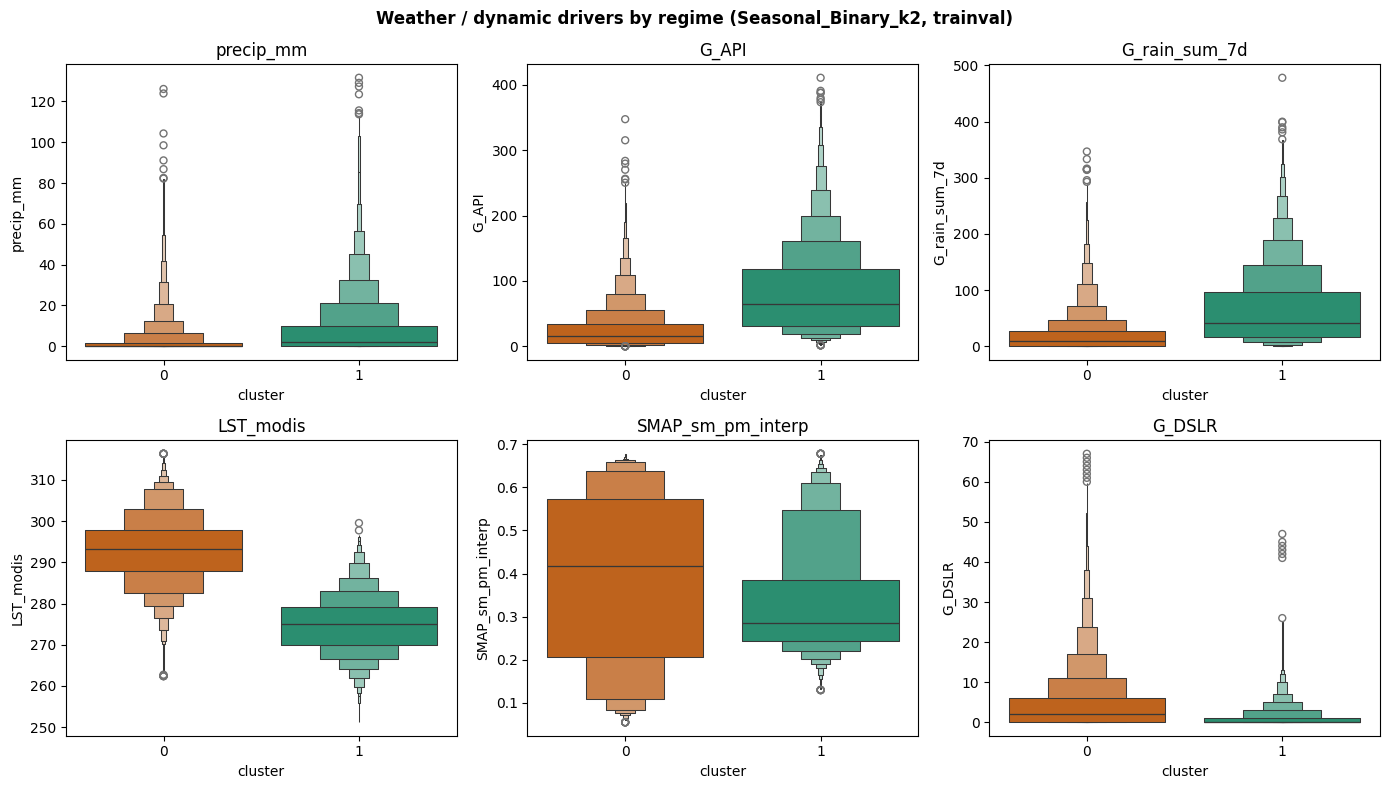


--- Static / environmental attributes per regime (trainval) ---
| feature                |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:-----------------------|------------------:|------------------:|------------------:|
| latitude               |            47.42  |            47.42  |             0.015 |
| longitude              |          -121.45  |          -121.45  |             0.036 |
| elev                   |          1160.53  |          1160.53  |            -0.041 |
| slope                  |            18.149 |            18.149 |            -0.068 |
| J_soil_texture_usda_b0 |             7     |             7     |            -0.033 |
| J_lc_code              |            10     |            10     |            -0.008 |
| J_bio_bio13            |           320     |           320     |            -0.052 |


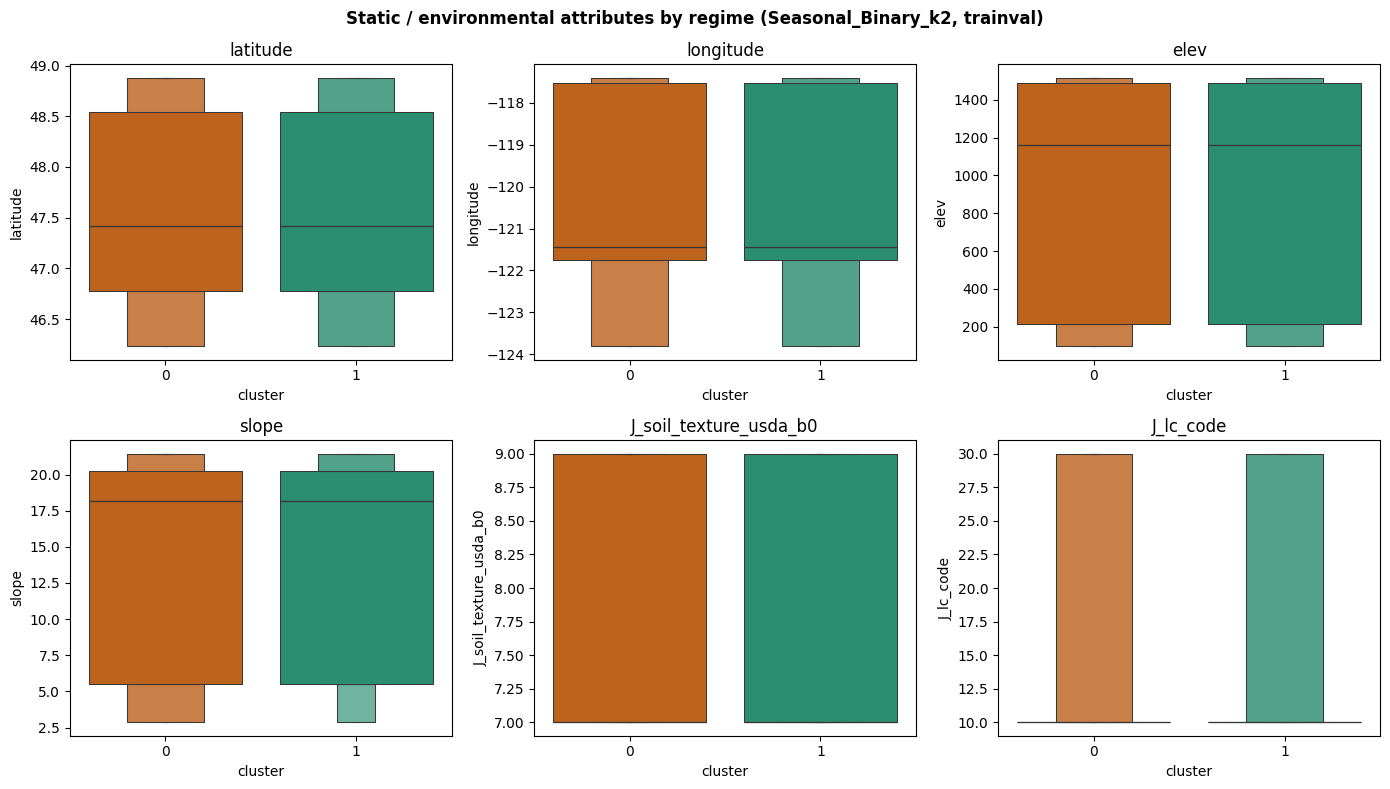


--- Top 15 V0 features separating the regimes (trainval; r > 0 => higher in cluster 1) ---
| feature                      |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:-----------------------------|------------------:|------------------:|------------------:|
| V_ema_LST_modis_kobs30       |          292.915  |          274.733  |             0.917 |
| V_ema_G_API_kobs30           |           19.05   |           74.6919 |            -0.691 |
| V_rollmin_G_API_kobs14       |            8.5636 |           42.9966 |            -0.689 |
| V_rollmax_G_API_kobs30       |           36.6247 |          132      |            -0.657 |
| V_rollmax_G_API_kobs7        |           21.7216 |           84.0855 |            -0.646 |
| V_rollrng_G_API_kobs30       |           28.077  |           90.2012 |            -0.614 |
| V_ema_F_NDVI_kobs30          |            0.4941 |            0.3008 |             0.387 |
| s2_b11                       |            0.1452 |            0.1027 

In [6]:
interpret_regimes("Seasonal_Binary_k2")

### 3.4 Univariate_G_API_k2

The G_API median-threshold router (fitted on trainval, as in eval-1.1) splits rows by antecedent wetness. The analysis shows whether that threshold behaves like a wet/dry state (temporal) or like a station split (geographic).


INTERPRETATION: Univariate_G_API_k2

--- Regime sizes ---
| split    |   cluster |    n | share   |
|:---------|----------:|-----:|:--------|
| trainval |         0 | 7304 | 50.0%   |
| trainval |         1 | 7304 | 50.0%   |
| test     |         0 | 3513 | 53.1%   |
| test     |         1 | 3107 | 46.9%   |

--- Target (soil_moisture_5cm) statistics per regime (trainval) ---
|   cluster |    n |   mean |    std |   p10 |   p50 |   p90 |   mean_shift_vs_global |
|----------:|-----:|-------:|-------:|------:|------:|------:|-----------------------:|
|         0 | 7304 | 0.1764 | 0.1188 | 0.026 | 0.164 | 0.334 |                -0.0419 |
|         1 | 7304 | 0.2602 | 0.0751 | 0.174 | 0.267 | 0.347 |                 0.0419 |


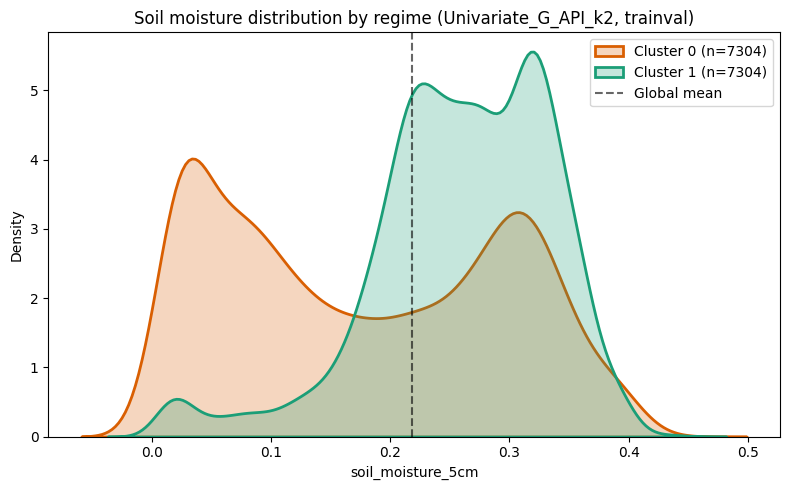


--- Share of rows in each cluster by month (1.0 = all rows of that month) ---
| month   |   ('test', 0) |   ('test', 1) |   ('trainval', 0) |   ('trainval', 1) |
|:--------|--------------:|--------------:|------------------:|------------------:|
| Jan     |         0.217 |         0.783 |             0.163 |             0.837 |
| Feb     |         0.217 |         0.783 |             0.184 |             0.816 |
| Mar     |         0.245 |         0.755 |             0.327 |             0.673 |
| Apr     |         0.41  |         0.59  |             0.378 |             0.622 |
| May     |         0.708 |         0.292 |             0.564 |             0.436 |
| Jun     |         0.776 |         0.224 |             0.628 |             0.372 |
| Jul     |         0.986 |         0.014 |             0.908 |             0.092 |
| Aug     |         0.881 |         0.119 |             0.974 |             0.026 |
| Sep     |         0.894 |         0.106 |             0.781 |             0.219

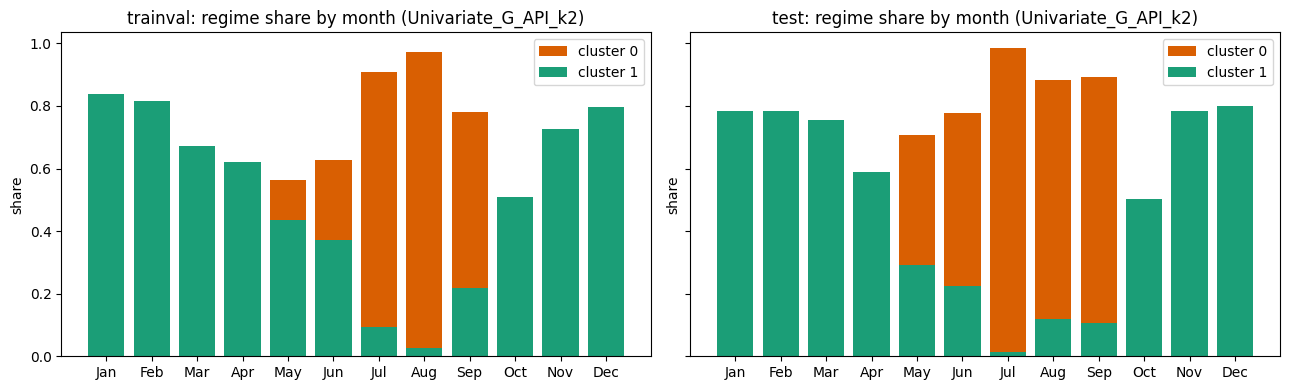


--- Share of each cluster per year ---
|   year |   ('test', 0) |   ('test', 1) |   ('trainval', 0) |   ('trainval', 1) |
|-------:|--------------:|--------------:|------------------:|------------------:|
|   2017 |       nan     |       nan     |             0.465 |             0.535 |
|   2018 |       nan     |       nan     |             0.527 |             0.473 |
|   2019 |       nan     |       nan     |             0.546 |             0.454 |
|   2020 |       nan     |       nan     |             0.472 |             0.528 |
|   2021 |       nan     |       nan     |             0.527 |             0.473 |
|   2022 |       nan     |       nan     |             0.461 |             0.539 |
|   2023 |         0.558 |         0.442 |           nan     |           nan     |
|   2024 |         0.497 |         0.503 |           nan     |           nan     |
|   2025 |         0.538 |         0.462 |           nan     |           nan     |

--- Station composition (trainval) ---
| stati

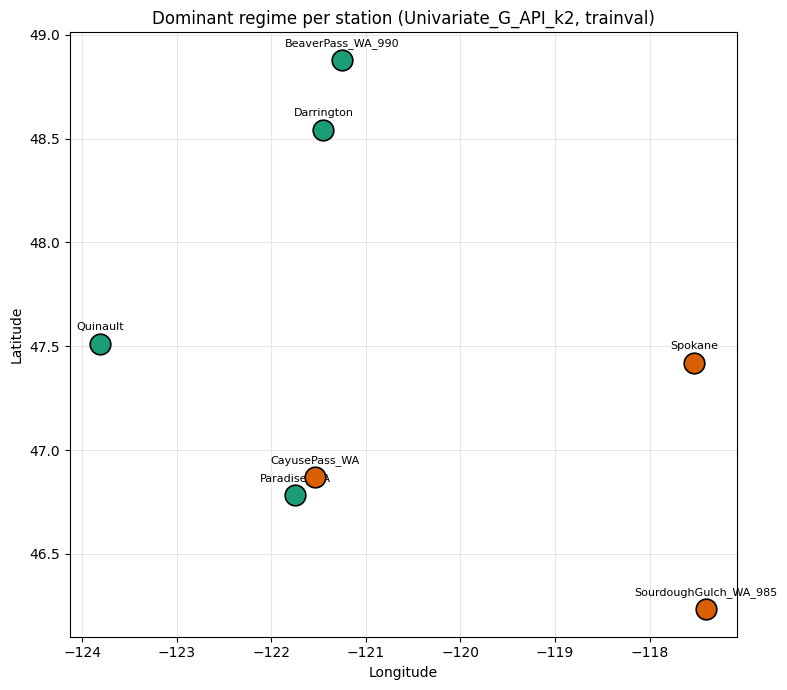


--- Station composition & purity on the TEST split (out-of-sample) ---
| station_id            |   n_test |   share_c0_test |   share_c1_test |   dominant_cluster_test |   purity_test |
|:----------------------|---------:|----------------:|----------------:|------------------------:|--------------:|
| Quinault              |     1044 |          0.2931 |          0.7069 |                       1 |        0.7069 |
| Paradise_WA           |     1067 |          0.3852 |          0.6148 |                       1 |        0.6148 |
| Darrington            |      999 |          0.3934 |          0.6066 |                       1 |        0.6066 |
| BeaverPass_WA_990     |      626 |          0.4201 |          0.5799 |                       1 |        0.5799 |
| CayusePass_WA         |     1081 |          0.4838 |          0.5162 |                       1 |        0.5162 |
| SourdoughGulch_WA_985 |      906 |          0.8422 |          0.1578 |                       0 |        0.8422 |
| Spokan

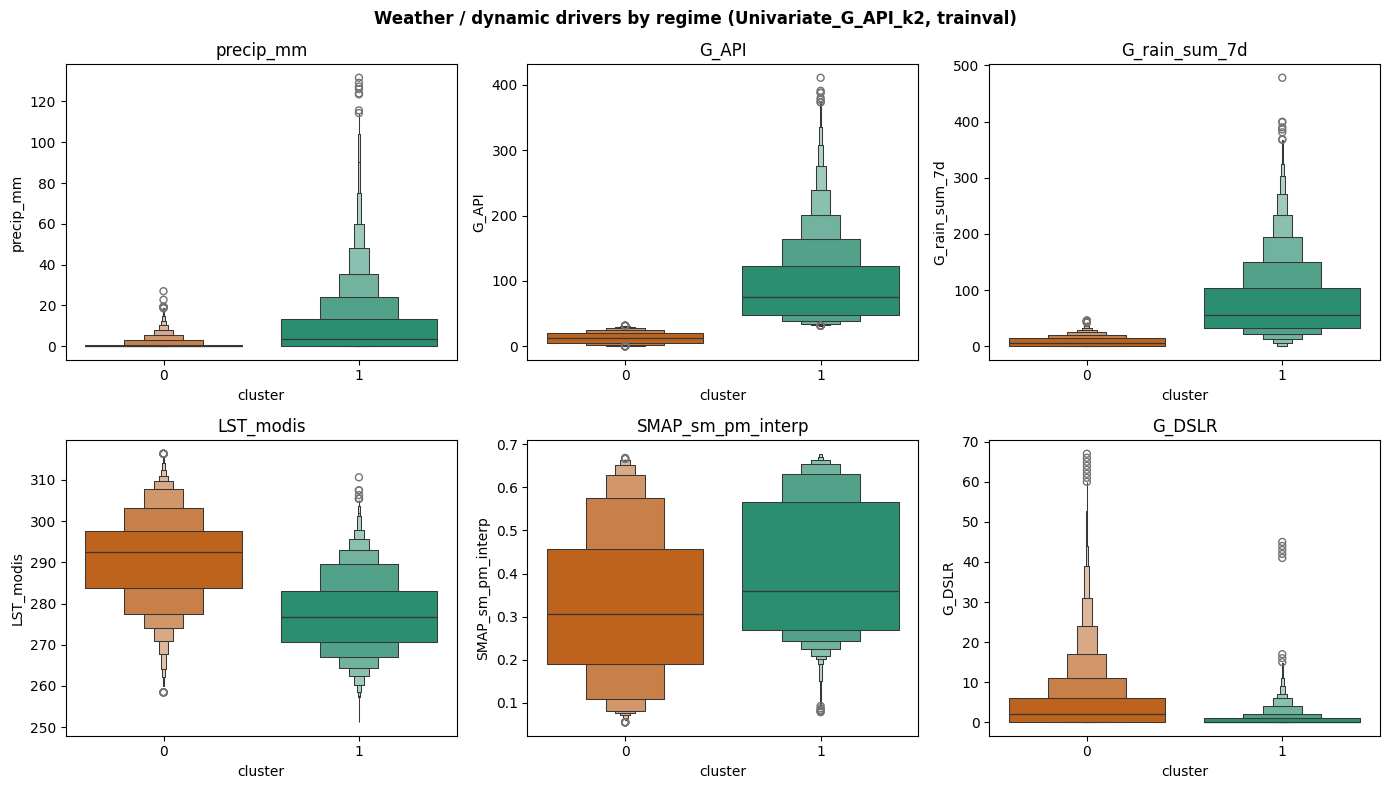


--- Static / environmental attributes per regime (trainval) ---
| feature                |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:-----------------------|------------------:|------------------:|------------------:|
| latitude               |            47.42  |            47.51  |            -0.202 |
| longitude              |          -121.255 |          -121.534 |             0.395 |
| elev                   |          1160.53  |          1205.09  |             0.049 |
| slope                  |            18.149 |            18.149 |            -0.018 |
| J_soil_texture_usda_b0 |             7     |             7     |            -0.042 |
| J_lc_code              |            10     |            10     |             0.137 |
| J_bio_bio13            |           204     |           391     |            -0.428 |


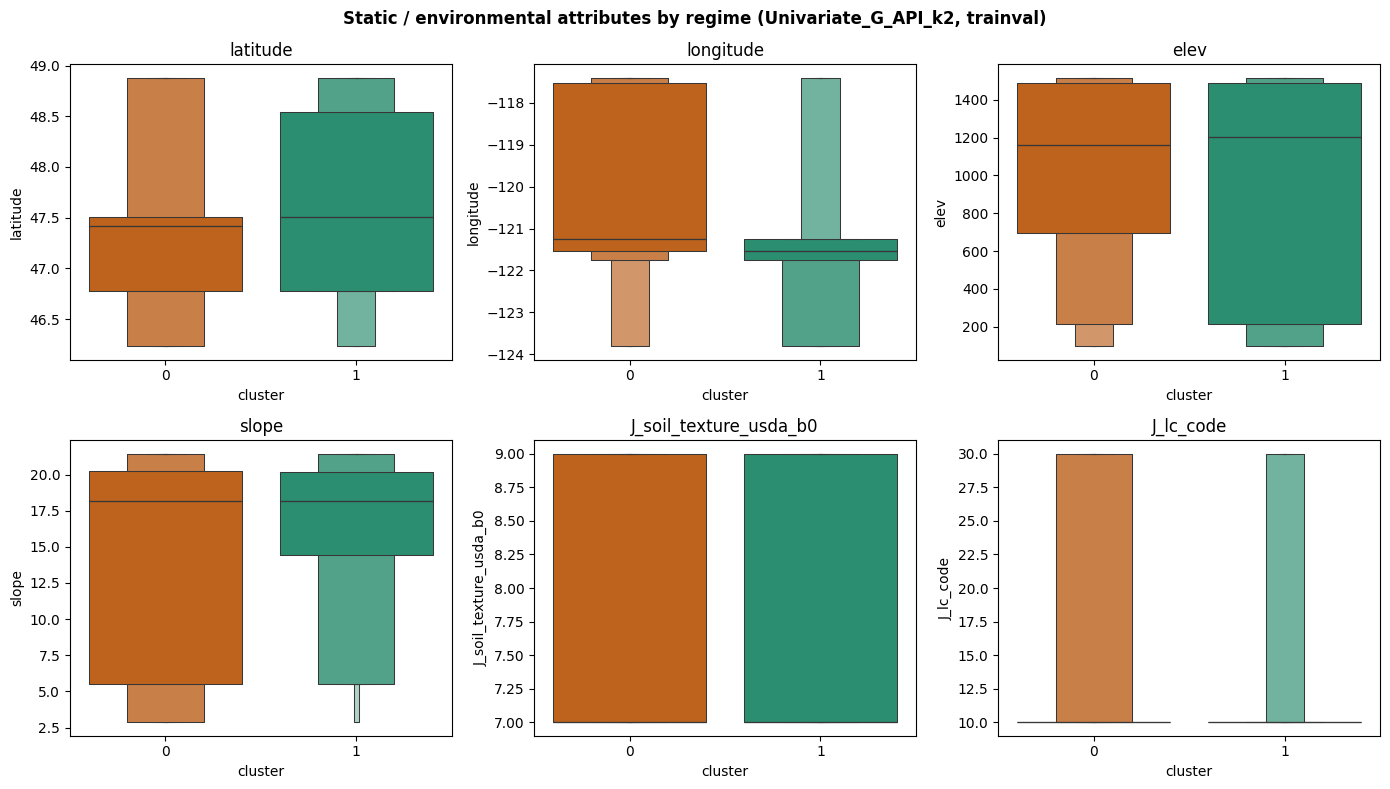


--- Top 15 V0 features separating the regimes (trainval; r > 0 => higher in cluster 1) ---
| feature                     |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:----------------------------|------------------:|------------------:|------------------:|
| V_rollmax_G_API_kobs7       |           17.2838 |           96.716  |            -0.985 |
| V_ema_G_API_kobs30          |           16.1074 |           79.1049 |            -0.917 |
| V_rollmax_G_API_kobs30      |           30.2972 |          138.909  |            -0.904 |
| V_rollmin_G_API_kobs14      |            7.5485 |           46.9168 |            -0.888 |
| V_rollrng_G_API_kobs30      |           22.7661 |           95.824  |            -0.868 |
| V_ema_LST_modis_kobs30      |          292.33   |          276.908  |             0.652 |
| F_MSI                       |            0.5633 |            0.4322 |             0.444 |
| V_rollmin_s2_b12_kobs30     |            0.0675 |            0.0457 |         

In [7]:
interpret_regimes("Univariate_G_API_k2")

### 3.5 Trained_Gating_k2

The learned XGBoost gate (trained on `soil_moisture_5cm < 0.16`, on the 50 V0 features) is the only strategy whose router was trained with the target in the loop (for gating only, not for the experts). Note it is refit on CPU here; its labels agree with eval-1.1 on 99.7% of test rows (section 2).


INTERPRETATION: Trained_Gating_k2

--- Regime sizes ---
| split    |   cluster |     n | share   |
|:---------|----------:|------:|:--------|
| trainval |         0 |  4181 | 28.6%   |
| trainval |         1 | 10427 | 71.4%   |
| test     |         0 |  1936 | 29.2%   |
| test     |         1 |  4684 | 70.8%   |

--- Target (soil_moisture_5cm) statistics per regime (trainval) ---
|   cluster |     n |   mean |    std |   p10 |   p50 |   p90 |   mean_shift_vs_global |
|----------:|------:|-------:|-------:|------:|------:|------:|-----------------------:|
|         0 |  4181 | 0.0717 | 0.0452 | 0.017 | 0.067 | 0.139 |                -0.1466 |
|         1 | 10427 | 0.2771 | 0.0584 | 0.196 | 0.28  | 0.351 |                 0.0588 |


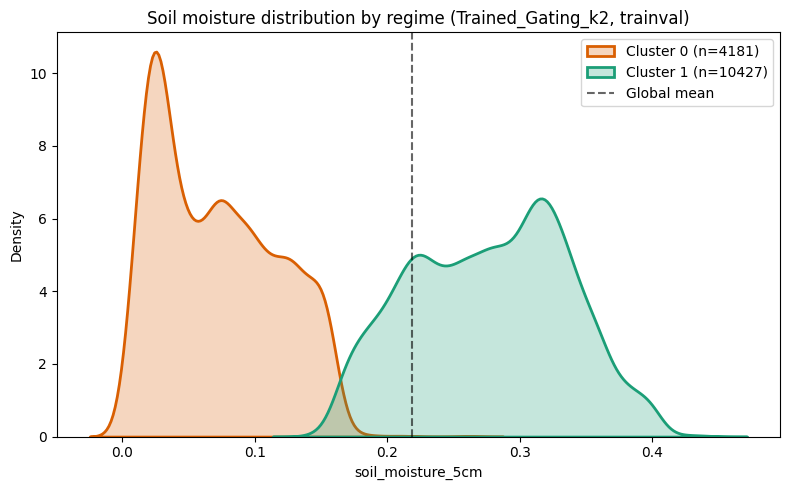


--- Share of rows in each cluster by month (1.0 = all rows of that month) ---
| month   |   ('test', 0) |   ('test', 1) |   ('trainval', 0) |   ('trainval', 1) |
|:--------|--------------:|--------------:|------------------:|------------------:|
| Jan     |         0.002 |         0.998 |             0.01  |             0.99  |
| Feb     |         0     |         1     |             0     |             1     |
| Mar     |         0     |         1     |             0     |             1     |
| Apr     |         0     |         1     |             0.001 |             0.999 |
| May     |         0.082 |         0.918 |             0.089 |             0.911 |
| Jun     |         0.35  |         0.65  |             0.232 |             0.768 |
| Jul     |         0.796 |         0.204 |             0.569 |             0.431 |
| Aug     |         0.891 |         0.109 |             0.923 |             0.077 |
| Sep     |         0.862 |         0.138 |             0.821 |             0.179

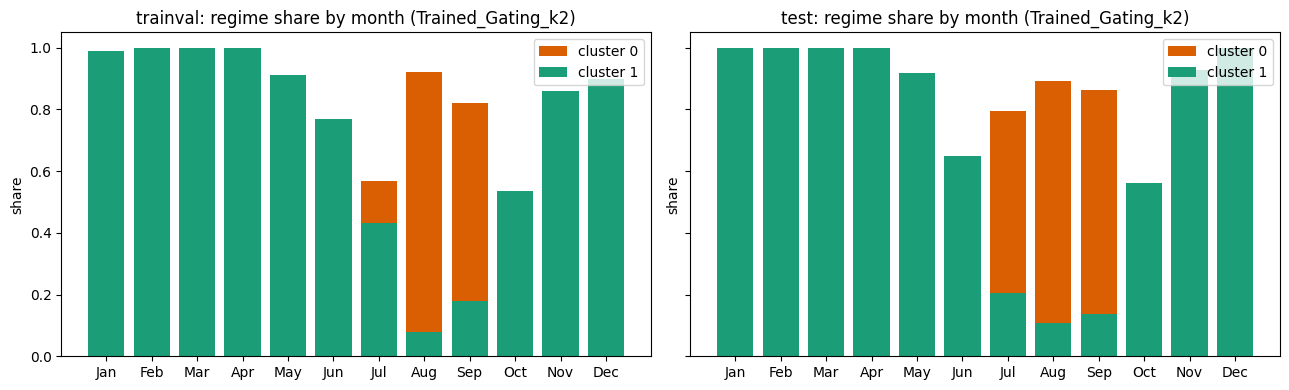


--- Share of each cluster per year ---
|   year |   ('test', 0) |   ('test', 1) |   ('trainval', 0) |   ('trainval', 1) |
|-------:|--------------:|--------------:|------------------:|------------------:|
|   2017 |       nan     |       nan     |             0.316 |             0.684 |
|   2018 |       nan     |       nan     |             0.351 |             0.649 |
|   2019 |       nan     |       nan     |             0.216 |             0.784 |
|   2020 |       nan     |       nan     |             0.243 |             0.757 |
|   2021 |       nan     |       nan     |             0.29  |             0.71  |
|   2022 |       nan     |       nan     |             0.302 |             0.698 |
|   2023 |         0.34  |         0.66  |           nan     |           nan     |
|   2024 |         0.249 |         0.751 |           nan     |           nan     |
|   2025 |         0.287 |         0.713 |           nan     |           nan     |

--- Station composition (trainval) ---
| stati

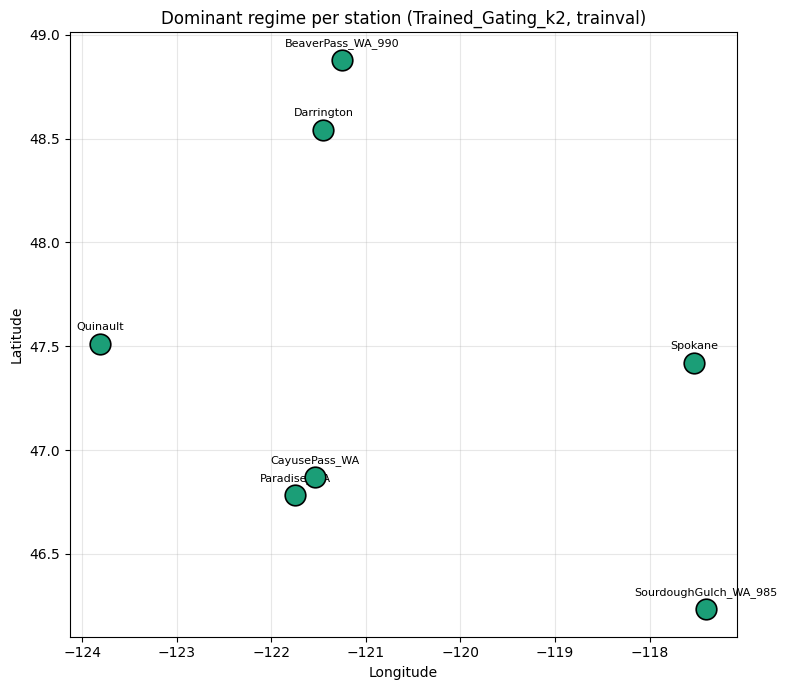


--- Station composition & purity on the TEST split (out-of-sample) ---
| station_id            |   n_test |   share_c0_test |   share_c1_test |   dominant_cluster_test |   purity_test |
|:----------------------|---------:|----------------:|----------------:|------------------------:|--------------:|
| BeaverPass_WA_990     |      626 |          0.0895 |          0.9105 |                       1 |        0.9105 |
| Quinault              |     1044 |          0.2308 |          0.7692 |                       1 |        0.7692 |
| SourdoughGulch_WA_985 |      906 |          0.234  |          0.766  |                       1 |        0.766  |
| Paradise_WA           |     1067 |          0.2755 |          0.7245 |                       1 |        0.7245 |
| Darrington            |      999 |          0.3263 |          0.6737 |                       1 |        0.6737 |
| CayusePass_WA         |     1081 |          0.3302 |          0.6698 |                       1 |        0.6698 |
| Spokan

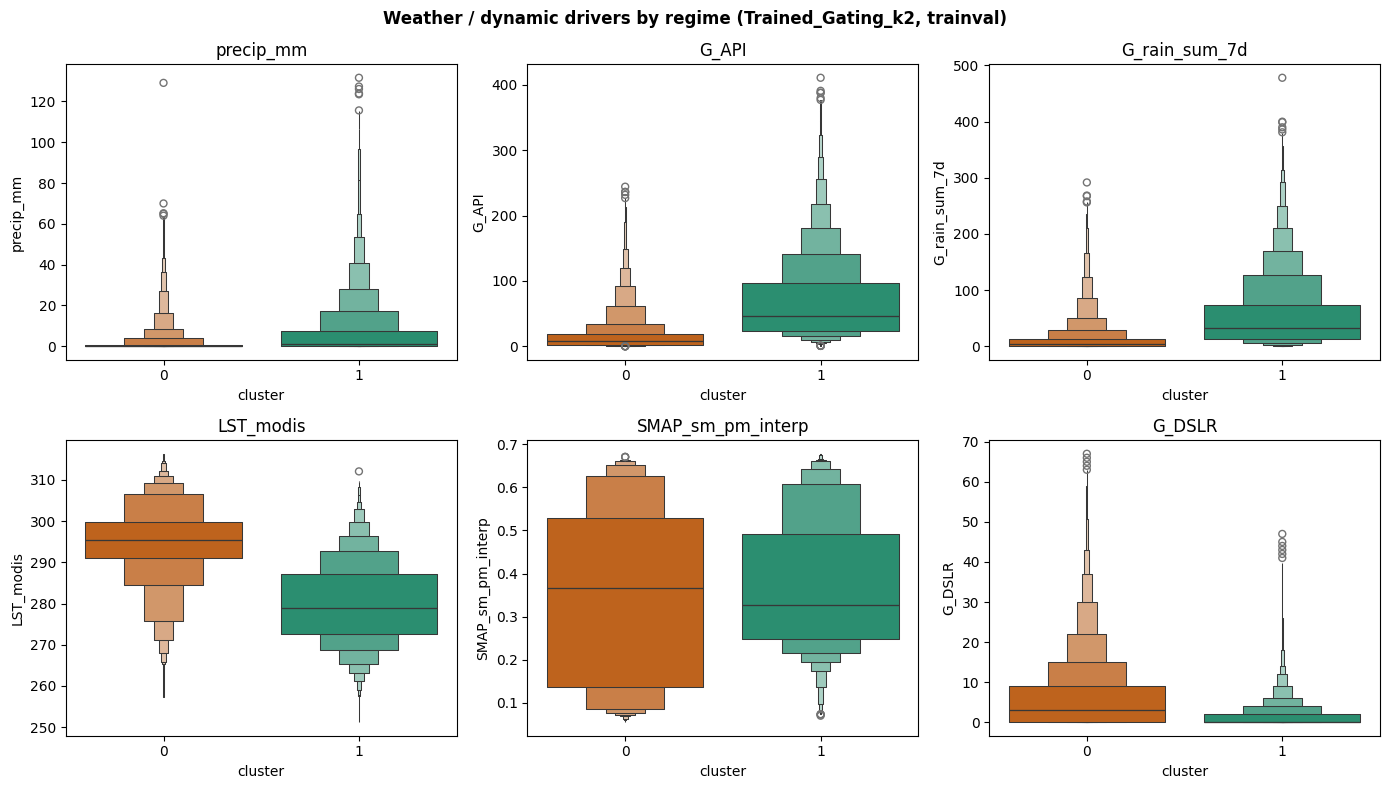


--- Static / environmental attributes per regime (trainval) ---
| feature                |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:-----------------------|------------------:|------------------:|------------------:|
| latitude               |            47.42  |            47.42  |            -0.11  |
| longitude              |          -121.45  |          -121.45  |             0.037 |
| elev                   |          1160.53  |          1160.53  |            -0.022 |
| slope                  |            18.149 |            18.149 |            -0.051 |
| J_soil_texture_usda_b0 |             7     |             7     |            -0.096 |
| J_lc_code              |            10     |            10     |             0.003 |
| J_bio_bio13            |           320     |           320     |            -0.065 |


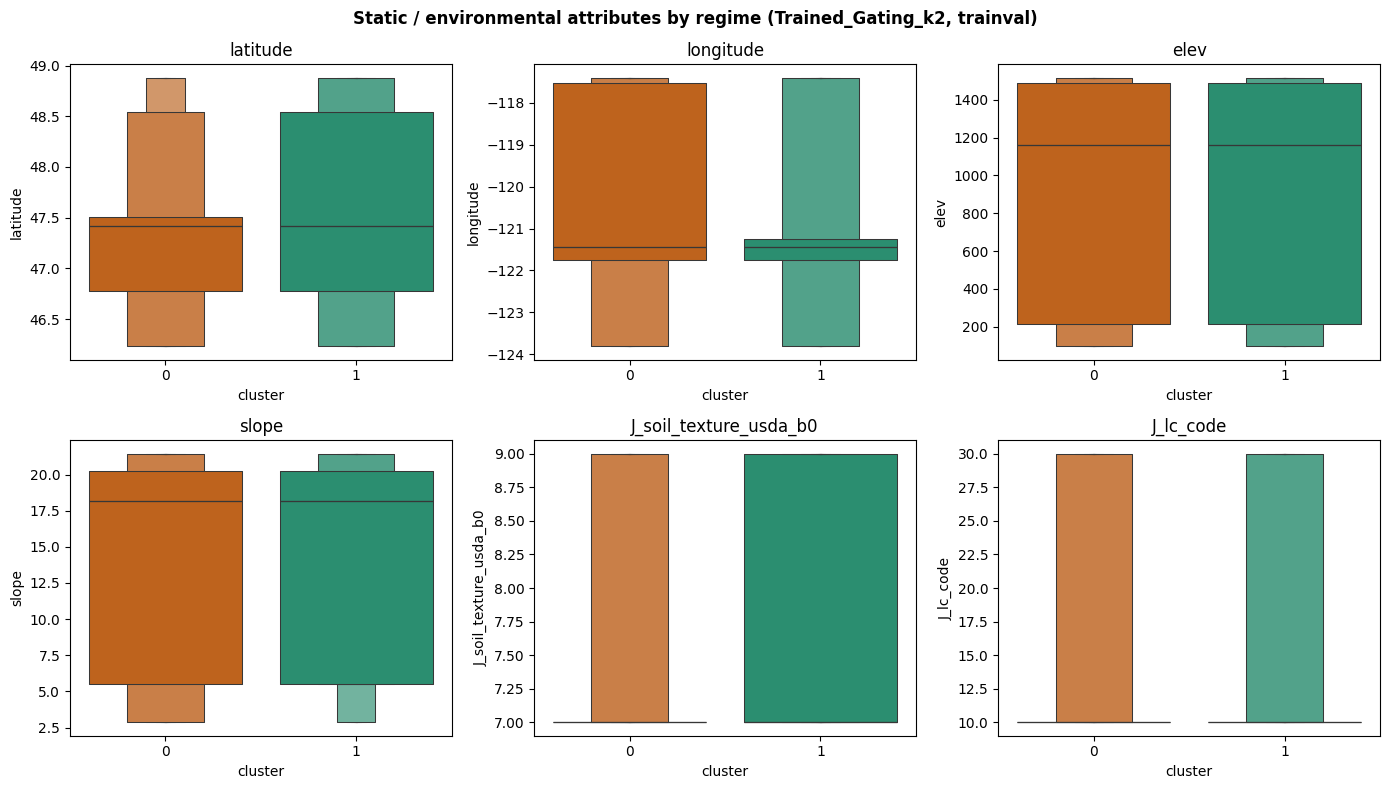


--- Top 15 V0 features separating the regimes (trainval; r > 0 => higher in cluster 1) ---
| feature                      |   median_cluster0 |   median_cluster1 |   rank_biserial_r |
|:-----------------------------|------------------:|------------------:|------------------:|
| V_ema_LST_modis_kobs30       |          295.493  |          278.747  |             0.807 |
| V_rollmin_G_API_kobs14       |            3.5215 |           30.3106 |            -0.777 |
| V_ema_G_API_kobs30           |            9.871  |           51.9006 |            -0.77  |
| V_rollmax_G_API_kobs7        |           10.6317 |           60.5348 |            -0.727 |
| V_rollmax_G_API_kobs30       |           19.9755 |           89.9565 |            -0.712 |
| V_rollrng_G_API_kobs30       |           17.2734 |           62.7706 |            -0.645 |
| V_rollmean_F_NDMI_kobs30     |            0.3031 |            0.3797 |            -0.391 |
| F_MSI                        |            0.5386 |            0.4506 

In [8]:
interpret_regimes("Trained_Gating_k2")

## 4. Cross-strategy comparison

The per-strategy analyses above are verbose by design; this section condenses them into one view: for each strategy, the regime sizes, mean station purity (trainval and out-of-sample test), which stations dominate which cluster, the single most separating V0 feature, the target distribution per regime, and the winner test R², RMSE, MAE and bias from eval-1.1 (for context, not computed here) — plus the winner's per-year test R² (2023 / 2024 / 2025), i.e. the temporal performance, and the winner's per-station test R² under the full and LOSO protocols from `derived_8.4-eval-1.4`, i.e. the spatial performance. The comparison table is exported as `regime_comparison_summary.csv` and the per-station spatial table as `regime_spatial_summary.csv`.


In [9]:
"""Cross-strategy comparison: station composition, purity, sizes, top features."""
# Winner test metrics per strategy from eval-1.1 (row with max pooled_r2 within each strategy).
eval_summary = pd.read_csv(EVAL_DIR / "metrics_summary.csv")
eval_winner = eval_summary.loc[eval_summary.groupby("strategy_name")["pooled_r2"].idxmax()].set_index("strategy_name")

comp_rows = []
for strategy in ROUTER_FACTORIES:
    lbl_tr = labels[(strategy, "trainval")]
    n_tr = len(lbl_tr)
    sizes = " / ".join(
        f"{int((lbl_tr == c).sum())} ({int((lbl_tr == c).sum()) / n_tr:.0%})"
        for c in sorted(np.unique(lbl_tr))
    )
    df_st = pd.read_csv(EXP_DIR / f"regime_station_composition_{strategy}.csv")
    groups = []
    for c in sorted(df_st["dominant_cluster"].unique()):
        stations = ", ".join(sorted(df_st.loc[df_st["dominant_cluster"] == c, "station_id"]))
        groups.append(f"c{c}: {stations}")
    top = pd.read_csv(EXP_DIR / f"regime_top_features_{strategy}.csv").iloc[0]
    comp_rows.append({
        "strategy": strategy,
        "trainval_sizes_c0_c1": sizes,
        "mean_purity_trainval": round(float(df_st["purity"].mean()), 3),
        "mean_purity_test": round(float(df_st["purity_test"].mean()), 3),
        "dominant_stations_per_cluster": "; ".join(groups),
        "top_separating_feature": f"{top['feature']} (r={top['rank_biserial_r']})",
        "winner_test_r2": round(float(eval_winner.loc[strategy, "pooled_r2"]), 4),
        "winner_test_rmse": round(float(eval_winner.loc[strategy, "pooled_rmse"]), 4),
        "winner_test_mae": round(float(eval_winner.loc[strategy, "pooled_mae"]), 4),
        "winner_test_bias": round(float(eval_winner.loc[strategy, "pooled_bias"]), 4),
        "winner_test_r2_2023": round(float(eval_winner.loc[strategy, "year_2023_r2"]), 4),
        "winner_test_r2_2024": round(float(eval_winner.loc[strategy, "year_2024_r2"]), 4),
        "winner_test_r2_2025": round(float(eval_winner.loc[strategy, "year_2025_r2"]), 4),
    })
df_comp = pd.DataFrame(comp_rows)
df_comp.to_csv(EXP_DIR / "regime_comparison_summary.csv", index=False)
print(df_comp.to_markdown(index=False))

# Per-year (temporal) winner test R²: 2023 / 2024 / 2025.
year_rows = []
for strategy in ROUTER_FACTORIES:
    year_rows.append({
        "strategy": strategy,
        "pooled_r2": round(float(eval_winner.loc[strategy, "pooled_r2"]), 4),
        "r2_2023": round(float(eval_winner.loc[strategy, "year_2023_r2"]), 4),
        "r2_2024": round(float(eval_winner.loc[strategy, "year_2024_r2"]), 4),
        "r2_2025": round(float(eval_winner.loc[strategy, "year_2025_r2"]), 4),
    })
df_year = pd.DataFrame(year_rows)
print("\n--- Winner test R² per year (eval-1.1, 2023-2025) ---")
print(df_year.to_markdown(index=False))

# Spatial (per-station) performance of the winner configs from eval-1.4 (LOSO experiment).
EVAL14_DIR = PROJECT_ROOT / "notebooks" / "experiment" / "derived_8.4-eval-1.4"
WINNER_CONFIGS = {
    "Clustering_V0_Full_k2": "Clustering_V0_Full_k2_c0_0_c1_10",
    "Clustering_Dynamic_k2": "Clustering_Dynamic_k2_c0_0_c1_0",
    "Seasonal_Binary_k2": "Seasonal_Binary_k2_c0_0_c1_0",
    "Univariate_G_API_k2": "Univariate_G_API_k2_c0_0_c1_0",
    "Trained_Gating_k2": "Trained_Gating_k2_c0_0_c1_0",
}
full_st = pd.read_csv(EVAL14_DIR / "full_per_config_station.csv")
loso_st = pd.read_csv(EVAL14_DIR / "loso_per_config_station.csv")

spatial_rows = []
for strategy, config_id in WINNER_CONFIGS.items():
    f = full_st[full_st["config_id"] == config_id].set_index("station")
    l = loso_st[loso_st["config_id"] == config_id].set_index("station")
    for st in f.index:
        spatial_rows.append({
            "strategy": strategy,
            "station": st,
            "full_r2": round(float(f.loc[st, "r2"]), 4),
            "full_rmse": round(float(f.loc[st, "rmse"]), 4),
            "loso_r2": round(float(l.loc[st, "r2"]), 4),
            "loso_rmse": round(float(l.loc[st, "rmse"]), 4),
        })
df_spatial = pd.DataFrame(spatial_rows)
df_spatial.to_csv(EXP_DIR / "regime_spatial_summary.csv", index=False)

full_pivot = df_spatial.pivot(index="station", columns="strategy", values="full_r2")
print("\n--- Per-station test R², full protocol (eval-1.4 full_per_config_station.csv) ---")
print(full_pivot.round(3).to_markdown())
loso_pivot = df_spatial.pivot(index="station", columns="strategy", values="loso_r2")
print("\n--- Per-station test R², LOSO held-out (eval-1.4 loso_per_config_station.csv) ---")
print(loso_pivot.round(3).to_markdown())

loso_sum = pd.read_csv(EVAL14_DIR / "loso_config_summary.csv")
agg_rows = []
for strategy, config_id in WINNER_CONFIGS.items():
    r = loso_sum[loso_sum["config_id"] == config_id].iloc[0]
    agg_rows.append({
        "strategy": strategy,
        "loso_mean_r2": round(float(r["loso_mean_r2"]), 4),
        "loso_pooled_r2": round(float(r["loso_pooled_r2"]), 4),
        "temporal_test_r2": round(float(r["temporal_test_r2"]), 4),
        "loso_minus_test_r2": round(float(r["loso_minus_test_r2"]), 4),
        "best_station": r["best_station"],
        "worst_station": r["worst_station"],
    })
df_loso_agg = pd.DataFrame(agg_rows)
print("\n--- LOSO aggregates (eval-1.4 loso_config_summary.csv) ---")
print(df_loso_agg.to_markdown(index=False))
print(f"\nSaved regime_spatial_summary.csv")

# Station x strategy matrix: share of cluster 1 per station (trainval).
matrix_rows = []
for strategy in ROUTER_FACTORIES:
    df_st = pd.read_csv(EXP_DIR / f"regime_station_composition_{strategy}.csv")
    for _, r in df_st.iterrows():
        matrix_rows.append({"station_id": r["station_id"], "strategy": strategy, "share_c1": r["share_c1"]})
df_matrix = pd.DataFrame(matrix_rows).pivot(index="station_id", columns="strategy", values="share_c1")
print("\n--- Share of cluster 1 per station (trainval; 1.0 = station entirely in cluster 1) ---")
print(df_matrix.round(3).to_markdown())

# Target distribution per regime per strategy (trainval).
target_rows = []
for strategy in ROUTER_FACTORIES:
    lbl_tr = labels[(strategy, "trainval")]
    for c in sorted(np.unique(lbl_tr)):
        s = trainval.loc[lbl_tr == c, TARGET]
        target_rows.append({
            "strategy": strategy,
            "cluster": c,
            "median": round(float(s.median()), 4),
            "mean": round(float(s.mean()), 4),
            "p10": round(float(s.quantile(0.10)), 4),
            "p90": round(float(s.quantile(0.90)), 4),
        })
df_target = pd.DataFrame(target_rows)
print("\n--- Target (soil_moisture_5cm) distribution per regime (trainval) ---")
print(df_target.to_markdown(index=False))


| strategy              | trainval_sizes_c0_c1     |   mean_purity_trainval |   mean_purity_test | dominant_stations_per_cluster                                                                               | top_separating_feature           |   winner_test_r2 |   winner_test_rmse |   winner_test_mae |   winner_test_bias |   winner_test_r2_2023 |   winner_test_r2_2024 |   winner_test_r2_2025 |
|:----------------------|:-------------------------|-----------------------:|-------------------:|:------------------------------------------------------------------------------------------------------------|:---------------------------------|-----------------:|-------------------:|------------------:|-------------------:|----------------------:|----------------------:|----------------------:|
| Clustering_V0_Full_k2 | 10624 (73%) / 3984 (27%) |                  1     |              1     | c0: BeaverPass_WA_990, CayusePass_WA, Darrington, Paradise_WA, Quinault; c1: SourdoughGulch_WA_985, Spokane

## 5. Synthesis: what each strategy's regimes physically mean

The five strategies sort into two families (numbers from the executed tables above; target medians on trainval):

**Station-geographic (regional) routing — only `Clustering_V0_Full_k2`.** Purity 1.000 on trainval and test: cluster 1 = the two semi-arid eastern stations (Spokane, SourdoughGulch), cluster 0 = the five wet, cool, forested western/mountain stations (BeaverPass, CayusePass, Darrington, Paradise, Quinault). The target distributions overlap heavily (median 0.239 vs 0.244) and the cluster-1 share is nearly uniform across months (0.22–0.30): the split is *not* wet/dry and *not* seasonal — it separates on regional climate & land-surface state (top separators are static: `K_aspect_cos`, `J_bio_bio15`, `J_clay_wfrac_b100`, all |r| = 1.0).

**Temporal wet/dry state routing — the other four.** They all split the year into a wet/cool regime (cluster 1) and a dry/warm regime (cluster 0), and their target medians separate sharply (≈ 0.16–0.17 vs ≈ 0.27–0.28) — the opposite of V0-Full. They differ in what drives the split and how much station geography leaks in:

- `Seasonal_Binary_k2` (R² = 0.7698) is the pure calendar split (dry May–Oct / wet Nov–Apr); per-station purity ≈ 0.53 is a calendar artifact, and static attributes show no separation (all |r| < 0.07).
- `Clustering_Dynamic_k2` (R² = 0.7866) learns nearly the same calendar wet/dry states from 3 dynamic features (cluster-1 share 98.8% in Jan → 0% in Jul), but with an eastern-dry bias: Spokane (15% cluster 1) and SourdoughGulch (30%) stay in the dry regime even during the wet season (mean purity 0.62). It is the best of the temporal family.
- `Univariate_G_API_k2` (R² = 0.7696) thresholds antecedent wetness at the trainval median: the eastern stations fall below it most of the time (Spokane 95% of rows in cluster 0, SourdoughGulch 73%) and the western ones above it (Quinault 74%, Darrington 67% in cluster 1), giving the clearest station gradient of the temporal family — yet wet-season episodes push western stations across and dry spells pull eastern ones over, so the split remains a wet/dry state, not a station split.
- `Trained_Gating_k2` (R² = 0.7355) is trained directly on `soil_moisture_5cm < 0.16`, so its regimes are pure wet/dry target states (median 0.067 vs 0.280 — the sharpest target separation); every station straddles both regimes (cluster-1 share 0.55–0.87 per station, Spokane lowest) and dry episodes in Jun–Sep are captured as cluster 0.

The eval-1.1 ranking (0.8150 / 0.7866 / 0.7698 / 0.7696 / 0.7355) lines up with the family structure: the only router whose regimes are *clean regional specialists* is the winner. Routers whose regimes are wet/dry temporal states — even with a geographic bias, like Dynamic — leave each expert with a more heterogeneous job, and the pooled test R² drops. The winning model's advantage is therefore not "two experts" per se — it is that its experts are regional specialists, which is exactly the within-state spatial generalization mode needed for the ECE team's new in-situ stations.
